# copy data

In [2]:
from google.colab import drive
%reload_ext google.colab.data_table
repo_path = 'fyp/fyp_resources' # path in your gdrive to the repo
content_path = f'/content/drive/MyDrive/{repo_path}' # path to gitrepo in gdrive after mounting
drive.mount('/content/drive/') # Outputs will be saved in your google drive

Mounted at /content/drive/


In [19]:
%pip install spacy

In [33]:
# prompt: install spacy "en_core_web_trf" to env

!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 2.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
import spacy
nlp = spacy.load("en_core_web_trf")

/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import textstat

# common plotting functions

In [36]:
import re
import pandas as pd

def merge_identical_base_rag_columns(
    df: pd.DataFrame,
    *,
    exclude_prefixes=('mnli_label', 'mnli_probs', 'num_entailments')
) -> pd.DataFrame:
    """
    For each metric X where both X_base and X_base_rag exist,
    assert they are equal rowwise, then:
      - create a new column 'X' with that common value
      - drop the original X_base and X_base_rag

    Any metric whose name starts with one of `exclude_prefixes`
    is skipped (so your MNLI labels, MNLI probs, and num_entailments stay as-is).

    Additionally, if the rag-to-ref columns for mnli_probs or mnli_label
    are missing, we populate them from `base_found_match` or `rag_found_match`.
    """
    out = df.copy()

    # Ensure rag-to-ref columns exist for mnli_probs and mnli_label
    if 'mnli_probs_base_rag_to_ref' not in out.columns and 'base_found_match' in out.columns:
        out['mnli_probs_base_rag_to_ref'] = out['base_found_match']
    if 'mnli_label_base_rag_to_ref' not in out.columns and 'rag_found_match' in out.columns:
        out['mnli_label_base_rag_to_ref'] = out['rag_found_match']

    # find all metrics which have both *_base and *_base_rag
    metrics = set()
    for col in out.columns:
        m = re.match(r'^(?P<metric>.+)_base$', col)
        if m:
            metrics.add(m.group('metric'))
    # intersect with those that actually have the rag version
    metrics &= {m for m in metrics if f"{m}_base_rag" in out.columns}

    for metric in metrics:
        # skip excluded prefixes
        if any(metric.startswith(pref) for pref in exclude_prefixes):
            continue

        col_base = f"{metric}_base"
        col_rag  = f"{metric}_base_rag"

        # sanity check: values must be identical
        if not out[col_base].equals(out[col_rag]):
            raise ValueError(
                f"Column values differ for '{col_base}' vs '{col_rag}'."
            )

        # collapse into a single column
        out[metric] = out[col_base]
        out.drop([col_base, col_rag], axis=1, inplace=True)

    return out


In [37]:
import json
import ast

import pandas as pd
import textstat
from scipy.stats import spearmanr

def correlation(df_full, dialect=False, em=False, sample_n=3000, random_state=42):
    # 1) Sample
    df = df_full.sample(n=sample_n, random_state=random_state).reset_index(drop=True)

    # 2) Base feature engineering
    # a) NER count on prompt
    df['num_ner'] = df['prompt'].apply(
        lambda txt: len(nlp(txt).ents) if isinstance(txt, str) else 0
    )
    # b) Word counts
    df['q_word_count'] = df['prompt'].apply(
        lambda txt: len(str(txt).split()) if isinstance(txt, str) else 0
    )
    df['ans_word_count'] = df['base_rag'].apply(
        lambda txt: len(str(txt).split()) if isinstance(txt, str) else 0
    )
    # c) FK & DC: coerce to numeric, fill NaNs with mean
    df['fk_score'] = pd.to_numeric(df['fk_score'], errors='coerce')
    df['fk_score'].fillna(df['fk_score'].mean(), inplace=True)

    df['dc_score'] = pd.to_numeric(df['dc_score'], errors='coerce')
    df['dc_score'].fillna(df['dc_score'].mean(), inplace=True)

    # d) On-the-fly readability
    df['dale_chall'] = df['prompt'].apply(
        lambda txt: textstat.dale_chall_readability_score(txt) if isinstance(txt, str) else None
    )
    df['flesch_kincaid'] = df['prompt'].apply(
        lambda txt: textstat.flesch_kincaid_grade(txt) if isinstance(txt, str) else None
    )

    # 3) Optional dialect feature (only if requested and not already present)
    if dialect and 'num_dialect' not in df.columns:
        def extract_rules_count(md):
            try:
                # md might already be a dict, or a JSON/string-repr; handle both
                d = md if isinstance(md, dict) else json.loads(md)
                return len(d.get('rules', {}))
            except Exception:
                try:
                    d = ast.literal_eval(md)
                    return len(d.get('rules', {}))
                except Exception:
                    return 0

        df['num_dialect'] = df['metadata'].apply(extract_rules_count)

    # 4) Decide which metric to correlate against
    target = "rag_found_match" if em else "mnli_probs_base_rag_to_ref"

    # 5) Assemble features list
    features = [
        'num_ner', 'fk_score', 'dc_score',
        'q_word_count', 'ans_word_count',
        'dale_chall', 'flesch_kincaid'
    ]
    if dialect:
        features.append('num_dialect')

    # 6) Filter out any constant features
    variable_feats = [f for f in features if df[f].nunique(dropna=True) > 1]
    const_feats = set(features) - set(variable_feats)
    if const_feats:
        print(f"Skipping constant features: {sorted(const_feats)}")

    # 7) Compute Spearman correlations
    results = []
    for feat in variable_feats:
        rho, pval = spearmanr(df[feat], df[target], nan_policy='omit')
        results.append({
            'feature': feat,
            'spearman_rho': rho,
            'p_value': pval
        })

    # 8) Build result DataFrame, sort by absolute rho
    corr_df = (
        pd.DataFrame(results)
          .assign(abs_rho=lambda d: d['spearman_rho'].abs())
          .sort_values('abs_rho', ascending=False)
          .drop(columns='abs_rho')
          .reset_index(drop=True)
    )

    print(corr_df)
    return corr_df


In [38]:
# %%
import pandas as pd

def get_change_status(df, em=False):
    # 1) isolate base (layer 0) rows
    base = df[df['layer'] == 0]

    criteria = 'mnli_label_base_rag_to_ref' if not em else 'rag_found_match'
    # 2) define composite key (including prompt and gen_modelId)
    key_cols = ['question_id', 'para_type', 'gen_modelId']

    # 3) grab the positive vs negative base keys
    pos_keys = (
        base.loc[base[criteria] == 1, key_cols]
            .drop_duplicates()
    )
    neg_keys = (
        base.loc[base[criteria] == 0, key_cols]
            .drop_duplicates()
    )

    # 4) restrict to children (layer > 0)
    children = df[df['layer'] > 0]

    # 5) degraded: children of positive bases that flipped to 0
    degraded = (
        children
        .merge(pos_keys, on=key_cols, how='inner')
        .loc[lambda x: x[criteria] == 0]
    )

    # 6) stable:
    #    - children of positive bases that stayed 1
    stable_pos = (
        children
        .merge(pos_keys, on=key_cols, how='inner')
        .loc[lambda x: x[criteria] == 1]
    )
    #    - children of negative bases that stayed 0
    stable_neg = (
        children
        .merge(neg_keys, on=key_cols, how='inner')
        .loc[lambda x: x[criteria] == 0]
    )
    stable = pd.concat([stable_pos, stable_neg], ignore_index=True)

    # 7) improved: children of negative bases that flipped to 1
    improved = (
        children
        .merge(neg_keys, on=key_cols, how='inner')
        .loc[lambda x: x[criteria] == 1]
    )

    return degraded, stable, improved




def sample_against_root(df, status_df, sample_size=5, random_state=42, ans_type="base_rag"):
    # extract and dedupe the root rows
    roots = df[df['type']=='RootNode'][['question_id','prompt','base_rag','mnli_probs_base_rag_to_ref', 'mnli_label_base_rag_to_ref', 'gen_modelId', 'para_type']]
    roots = roots.drop_duplicates(subset=['question_id','gen_modelId','para_type'])

    # build quick lookup dicts
    prompt_map   = dict(zip(roots['question_id'], roots['prompt']))
    response_map = dict(zip(roots['question_id'], roots['base_rag']))
    mnli_map = dict(zip(roots['question_id'], roots['mnli_probs_base_rag_to_ref']))
    mnli_label_map = dict(zip(roots['question_id'], roots['mnli_label_base_rag_to_ref']))

    # sample the children
    # Ensure sample_size does not exceed the number of available rows
    actual_sample_size = min(sample_size, len(status_df))

    if actual_sample_size == 0:
        print(f"Warning: No rows available to sample from status_df (length {len(status_df)}). Returning empty DataFrame.")
        # Return a DataFrame with the expected columns, excluding 'gen_modelId'
        return pd.DataFrame(columns=[
            'base_rag_declarative',
            'reference_ans_declarative',
            'question_id',
            'possible_answers',
            'child_prompt',
            'child_response',
            'root_prompt',
            'root_response',
            'root_mnli_probs_base_rag_to_ref',
            'mnli_probs_base_rag_to_ref',
            'root_mnli_label',
            'mnli_label_base_rag_to_ref',
            'root_gen' # 'gen_modelId' was renamed to 'root_gen'
        ])


    # Sample with replacement if the population is smaller than the desired sample size,
    # otherwise sample without replacement.
    replace_sampling = actual_sample_size < sample_size

    sample = status_df.sample(n=actual_sample_size, replace=replace_sampling, random_state=random_state).copy()

    # map in the root info
    sample['root_prompt']   = sample['question_id'].map(prompt_map)
    sample['root_response'] = sample['question_id'].map(response_map)
    sample['root_mnli_probs_base_rag_to_ref'] = sample['question_id'].map(mnli_map)
    sample['root_mnli_label'] = sample['question_id'].map(mnli_label_map)
    # rename and select
    sample = sample.rename(columns={'prompt':'child_prompt',
                                    'base_rag':'child_response',
                                    'gen_modelId': 'root_gen'}) # 'gen_modelId' is renamed here

    # Return the selected columns, using the new name 'root_gen' instead of the old 'gen_modelId'
    return sample[[
        'base_rag_declarative',
        f'reference_ans_declarative',
        'question_id',
        f'possible_answers',
        'child_prompt',
        'child_response',
        'root_prompt',
        'root_response',
        'root_mnli_probs_base_rag_to_ref',
        'mnli_probs_base_rag_to_ref',
        'root_mnli_label',
        'mnli_label_base_rag_to_ref',
        'root_gen' # Use the new column name here
    ]]

In [39]:
import matplotlib.pyplot as plt


def summarise(summary_df, para_type='semantic'):
    """
    Filter the DataFrame by para_type and return a list of (model_id, df_model) tuples,
    where df_model is sorted by layer.
    """
    # Keep only rows matching the requested para_type
    filtered = summary_df[summary_df['para_type'] == para_type]

    # Identify unique model IDs
    models = filtered['gen_modelId'].unique()

    # Build a list of (model_id, df_model) pairs
    summary_list = []
    for model_id in models:
        df_model = (
            filtered[filtered['gen_modelId'] == model_id]
            .sort_values('layer')
        )
        summary_list.append((model_id, df_model))

    return summary_list

mtype_to_label = {
    'f1_1': 'F1',
    'rec_1': 'Recall',
    'pct': 'Percentage (ans entails ref)',
    'em_pct': 'EM Percentage (ans entails ref)'

}

def plot_from_summary(summary_list, mtype='f1_1'):
    """
    Take the list returned by summarise() and plot each model's Base vs. RAG F1
    on a single row (one subplot per model).
    """
    n_models = len(summary_list)

    # Create a 1×n_models grid
    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_models,
        figsize=(5 * n_models, 4),   # width = 5 per subplot, height = 4
        sharey=True                  # share the y-axis across all columns
    )

    # If there's only one model, wrap the single Axes in a list
    if n_models == 1:
        axes = [axes]


    # Loop through each (model_id, df_model) and plot
    for ax, (model_id, df_model) in zip(axes, summary_list):
        layers = df_model['layer']
        base_f1 = df_model[f'base_{mtype}']
        rag_f1  = df_model[f'rag_{mtype}']

        ax.plot(layers, base_f1, marker='o', label=f'Base {mtype_to_label[mtype]}')
        ax.plot(layers, rag_f1,  marker='s', label=f'RAG {mtype_to_label[mtype]}')
        ax.set_title(f'Model: {model_id}')
        ax.set_xlabel('Layer')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.legend()

    # Only the first subplot needs a y-axis label, since they're shared
    axes[0].set_ylabel(mtype)

    plt.tight_layout()
    plt.show()


In [40]:
def plot_progression(degraded_, stable_, improved_, para_type='semantic'):
  degraded = degraded_[degraded_["para_type"] == para_type]
  stable = stable_[stable_["para_type"] == para_type]
  improved = improved_[improved_["para_type"] == para_type]
  # Group by modelId and layer, then count the number of instances in each category
  degraded_counts_model = degraded.groupby(['gen_modelId', 'layer']).size().reset_index(name='Degraded')
  stable_counts_model = stable.groupby(['gen_modelId', 'layer']).size().reset_index(name='Stable')
  improved_counts_model = improved.groupby(['gen_modelId', 'layer']).size().reset_index(name='Improved')

  # Merge the counts into a single DataFrame per model
  model_layer_summary = pd.merge(degraded_counts_model, stable_counts_model, on=['gen_modelId', 'layer'], how='outer')
  model_layer_summary = pd.merge(model_layer_summary, improved_counts_model, on=['gen_modelId', 'layer'], how='outer')

  # Fill NaN values with 0
  model_layer_summary = model_layer_summary.fillna(0)

  # Calculate the total number of children nodes per model and layer
  model_layer_summary['Total'] = model_layer_summary['Degraded'] + model_layer_summary['Stable'] + model_layer_summary['Improved']

  # Calculate percentages
  model_layer_summary['Degraded_Percent'] = (model_layer_summary['Degraded'] / model_layer_summary['Total']) * 100
  model_layer_summary['Stable_Percent'] = (model_layer_summary['Stable'] / model_layer_summary['Total']) * 100
  model_layer_summary['Improved_Percent'] = (model_layer_summary['Improved'] / model_layer_summary['Total']) * 100

  # Get unique model IDs
  model_ids = model_layer_summary['gen_modelId'].unique()
  # Determine how many models we have
  n_models = len(model_ids)

  # Create a 1×n_models grid of subplots, sharing the same y‐axis
  fig, axes = plt.subplots(
      nrows=1,
      ncols=n_models,
      figsize=(5 * n_models, 6),
      sharey=True,
      constrained_layout=True
  )

  # If there’s only one model, axes won’t be an array—make it iterable
  if n_models == 1:
      axes = [axes]

  # Loop over each subplot and each model_id
  for ax, model_id in zip(axes, model_ids):
      # Filter, sort by layer, and set 'layer' as index
      df_model = (
          model_layer_summary[model_layer_summary['gen_modelId'] == model_id]
          .sort_values('layer')
          .set_index('layer')
          [['Degraded_Percent', 'Stable_Percent', 'Improved_Percent']]
      )

      # Use pandas’ grouped‐bar plot on this axis
      df_model.plot(
          kind='bar',
          ax=ax,
          width=0.8,   # total width allocated per layer
          rot=0        # keep x‐tick labels horizontal
      )

      # Title & labels
      ax.set_title(f'Model: {model_id}')
      ax.set_xlabel('Layer')
      if ax is axes[0]:
          ax.set_ylabel('Percentage of Nodes')
      else:
          ax.set_ylabel('')   # hide y‐label on all but the first subplot

      # Annotate each bar with its percentage
      for bar in ax.patches:
          height = bar.get_height()
          ax.annotate(
              f'{height:.1f}%',
              xy=(bar.get_x() + bar.get_width() / 2, height),
              xytext=(0, 3),
              textcoords='offset points',
              ha='center',
              va='bottom',
              fontsize=8
          )

      ax.grid(axis='y', linestyle='--', alpha=0.7)

  # Build a single legend for all subplots (showing Degraded / Stable / Improved)
  handles, labels = axes[-1].get_legend_handles_labels()
  fig.legend(handles, labels, title='Status',
            loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.02))

  plt.tight_layout(rect=[0, 0, 1, 0.95])
  plt.show()

# 'semantic', 'question_position_suffix', 'question_position_middle',
#        'sg_dialect', 'question_position_suffix;sg_dialect',
#        'question_position_middle;sg_dialect'], dtype=object)

In [41]:
def agg_df(df, group_by=['gen_modelId','para_type','layer'], use_em=False):
    rag_ac_key = 'rag_found_match' if use_em else 'mnli_label_base_rag_to_ref'
    b_ac_key = 'base_found_match' if use_em else 'mnli_label_base_to_ref'
    return (
        df.groupby(group_by)
          .agg(
            # Count True/False and percentage for `base_found_match`
            base_true      = (b_ac_key, 'sum'),
            base_false     = (b_ac_key, lambda x: (~x.astype(bool)).sum()),
            base_pct       = (b_ac_key, lambda x: x.mean() * 100),

            # Count True/False and percentage for `rag_found_match`
            rag_em_true    = ('rag_found_match', 'sum'),
            rag_em_false   = ('rag_found_match', lambda x: (~x.astype(bool)).sum()),
            rag_em_pct     = ('rag_found_match', lambda x: x.mean() * 100),

            # Count True/False and percentage for `rag_found_match`
            base_em_true    = ('base_found_match', 'sum'),
            base_em_false   = ('base_found_match', lambda x: (~x.astype(bool)).sum()),
            base_em_pct     = ('base_found_match', lambda x: x.mean() * 100),

            # Count True/False and percentage for `mnli_label_base_rag_to_ref`
            rag_true  = (rag_ac_key, 'sum'),
            rag_false = (rag_ac_key, lambda x: (~x.astype(bool)).sum()),
            rag_pct   = (rag_ac_key, lambda x: x.mean() * 100),

            # Averages of F1 / recall / precision columns
            base_f1_1      = ('base_f1_1', 'mean'),
            rag_f1_1       = ('rag_f1_1', 'mean'),
            base_f1_L      = ('base_f1_L', 'mean'),
            rag_f1_L       = ('rag_f1_L', 'mean'),
            base_rec_1     = ('base_rec_1', 'mean'),
            rag_rec_1      = ('rag_rec_1', 'mean'),
            base_rec_L     = ('base_rec_L', 'mean'),
            rag_rec_L      = ('rag_rec_L', 'mean'),
            base_prec_1    = ('base_prec_1', 'mean'),
            rag_prec_1     = ('rag_prec_1', 'mean'),
            base_prec_L    = ('base_prec_L', 'mean'),
            rag_prec_L     = ('rag_prec_L', 'mean'),
          )
          .reset_index()
    )


# albation: TQA and PQA para

### investegation question: what are the effects of paraphrasing on response?

In [ ]:
# load dataset
df_tqa = pd.read_csv('/content/drive/MyDrive/fyp/dataset/TQA-paraphrase-trees-merged.csv')
print(len(df_tqa), df_tqa.columns)

38103 Index(['question_id', 'gen_modelId', 'layer', 'id', 'type', 'para_type',
       'prompt', 'rag_closest_match', 'rag_entities', 'possible_answers',
       'metadata', 'wiki_title', 'rag_found_match', 'base_found_match',
       'base_f1_1', 'base_f1_L', 'rag_f1_1', 'rag_f1_L', 'base_rec_1',
       'base_rec_L', 'rag_rec_1', 'rag_rec_L', 'base_prec_1', 'base_prec_L',
       'rag_prec_1', 'rag_prec_L', 'root_similarity_score', 'complexity_score',
       'fk_score', 'dc_score', 'similarity', 'base', 'base_rag',
       'reference_ans_declarative', 'root_prompt', 'base_rag_sentences',
       'base_rag_entailment_probs', 'base_rag_entailment_labels',
       'num_entailments_base_rag', 'num_base_rag_sentences',
       'best_base_rag_sentence', 'base_rag_declarative',
       'mnli_label_base_rag_to_ref', 'mnli_probs_base_rag_to_ref'],
      dtype='object')


In [217]:
# load dataset
df_pop = pd.read_csv('/content/drive/MyDrive/fyp/dataset/POPQA-paraphrase-trees-merged.csv')
df_pop = merge_identical_base_rag_columns(df_pop)
print(len(df_pop), df_pop.columns)

counts = df_pop['gen_modelId'].value_counts()
counts_partype = df_pop.groupby(['gen_modelId', 'para_type', 'type']).size().reset_index(name='count')
print("\nCounts by gen_modelId and partype:")
counts_partype


28637 Index(['question_id', 'gen_modelId', 'layer', 'id', 'type', 'para_type',
       'prompt', 'base_rag_sentences', 'base_rag_entailment_labels',
       'base_rag_entailment_probs', 'num_entailments_base_rag',
       'num_base_rag_sentences', 'best_base_rag_sentence',
       'base_rag_declarative', 'mnli_label_base_rag_to_ref',
       'mnli_probs_base_rag_to_ref', 'base_sentences',
       'base_entailment_labels', 'base_entailment_probs',
       'num_entailments_base', 'num_base_sentences', 'best_base_sentence',
       'base_declarative', 'mnli_label_base_to_ref', 'mnli_probs_base_to_ref',
       'rag_prec_1', 'complexity_score', 'base_prec_1', 'rag_closest_match',
       'wiki_title', 'rag_prec_L', 'fk_score', 'base_found_match', 'rag_f1_L',
       'dc_score', 'rag_entities', 'base_rag', 'rag_found_match',
       'root_similarity_score', 'base_f1_L', 'base_prec_L', 'base_rec_1',
       'rag_f1_1', 'root_prompt', 'Unnamed: 0', 'reference_ans_declarative',
       'rag_rec_1', 'base', 

,gen_modelId,para_type,type,count
0,google/gemma-3-12b-it,semantic,RootNode,682
1,google/gemma-3-12b-it,semantic,SemanticNode,8221
2,google/gemma-3-12b-it,sg_dialect,TerminalNode,82
3,google/gemma-3-1b-it,semantic,RootNode,682
4,google/gemma-3-1b-it,semantic,SemanticNode,8221
5,google/gemma-3-1b-it,sg_dialect,TerminalNode,6083
6,mistralai/Mistral-7B-Instruct-v0.2,hk_dialect,TerminalNode,1214
7,mistralai/Mistral-7B-Instruct-v0.2,semantic,RootNode,257
8,mistralai/Mistral-7B-Instruct-v0.2,semantic,SemanticNode,3128
9,mistralai/Mistral-7B-Instruct-v0.2,sg_dialect,TerminalNode,67


In [219]:
df_pop.columns

Index(['question_id', 'gen_modelId', 'layer', 'id', 'type', 'para_type',
       'prompt', 'base_rag_sentences', 'base_rag_entailment_labels',
       'base_rag_entailment_probs', 'num_entailments_base_rag',
       'num_base_rag_sentences', 'best_base_rag_sentence',
       'base_rag_declarative', 'mnli_label_base_rag_to_ref',
       'mnli_probs_base_rag_to_ref', 'base_sentences',
       'base_entailment_labels', 'base_entailment_probs',
       'num_entailments_base', 'num_base_sentences', 'best_base_sentence',
       'base_declarative', 'mnli_label_base_to_ref', 'mnli_probs_base_to_ref',
       'rag_prec_1', 'complexity_score', 'base_prec_1', 'rag_closest_match',
       'wiki_title', 'rag_prec_L', 'fk_score', 'base_found_match', 'rag_f1_L',
       'dc_score', 'rag_entities', 'base_rag', 'rag_found_match',
       'root_similarity_score', 'base_f1_L', 'base_prec_L', 'base_rec_1',
       'rag_f1_1', 'root_prompt', 'Unnamed: 0', 'reference_ans_declarative',
       'rag_rec_1', 'base', 'base_

In [ ]:
counts_partype = df_tqa.groupby(['gen_modelId', 'para_type']).size().reset_index(name='count')
print("\nCounts by gen_modelId and partype:")
counts_partype


Counts by gen_modelId and partype:


,gen_modelId,para_type,count
0,google/gemma-3-12b-it,semantic,9017
1,google/gemma-3-12b-it,sg_dialect,2297
2,google/gemma-3-1b-it,semantic,9017
3,google/gemma-3-1b-it,sg_dialect,8755
4,mistralai/Mistral-7B-Instruct-v0.2,semantic,9017


In [183]:
# Usage:
degraded, stable, improved = get_change_status(df_tqa)

deg_sample = sample_against_root(df_tqa, degraded, sample_size=20)
stab_sample = sample_against_root(df_tqa, stable,   sample_size=5)
imp_sample  = sample_against_root(df_tqa, improved, sample_size=5)

print("=== Degraded vs Root ===")
for _, row in deg_sample.iterrows():
    print(f"question_id:    {row['question_id']}")
    print(f"child_prompt:   {row['child_prompt']}")
    print(f"child_response: {row['child_response']}")
    print(f"root_prompt:    {row['root_prompt']}")
    print(f"root_response:  {row['root_response']}")
    print(f"possible answers:  {row['possible_answers']}")
    print(f"reference_ans_declarative:  {row['reference_ans_declarative']}")
    print(f"base_rag_declarative:  {row['base_rag_declarative']}")
    print(f"mnli_label_base_rag_to_ref:  {row['mnli_label_base_rag_to_ref']}")
    print(f"root_mnli_label:  {row['root_mnli_label']}")
    print("-" * 40)

print("\n=== Stable vs Root ===")
for _, row in stab_sample.iterrows():
    print(f"question_id:    {row['question_id']}")
    print(f"child_prompt:   {row['child_prompt']}")
    print(f"child_response: {row['child_response']}")
    print(f"root_prompt:    {row['root_prompt']}")
    print(f"root_response:  {row['root_response']}")
    print(f"possible answers:  {row['possible_answers']}")
    print(f"reference_ans_declarative:  {row['reference_ans_declarative']}")
    print(f"base_rag_declarative:  {row['base_rag_declarative']}")
    print(f"mnli_label_base_rag_to_ref:  {row['mnli_label_base_rag_to_ref']}")
    print(f"root_mnli_label:  {row['root_mnli_label']}")
    print("-" * 40)

print("\n=== Improved vs Root ===")
for _, row in imp_sample.iterrows():
    print(f"question_id:    {row['question_id']}")
    print(f"child_prompt:   {row['child_prompt']}")
    print(f"child_response: {row['child_response']}")
    print(f"root_prompt:    {row['root_prompt']}")
    print(f"root_response:  {row['root_response']}")
    print(f"possible answers:  {row['possible_answers']}")
    print(f"reference_ans_declarative:  {row['reference_ans_declarative']}")
    print(f"base_rag_declarative:  {row['base_rag_declarative']}")
    print(f"mnli_label_base_rag_to_ref:  {row['mnli_label_base_rag_to_ref']}")
    print(f"root_mnli_label:  {row['root_mnli_label']}")
    print("-" * 40)


=== Degraded vs Root ===
question_id:    40454
child_prompt:   What girl group did Louise Redknapp perform with?
child_response: Eternal performed with Power of a Woman.
root_prompt:    Louise Redknapp was a member of which all girl pop group?
root_response:  Eternal
possible answers:  ['ETERNAL']
reference_ans_declarative:  ETERNAL Louise Redknapp was a member of the all girl pop group.
base_rag_declarative:  nan
mnli_label_base_rag_to_ref:  0
root_mnli_label:  1
----------------------------------------
question_id:    13974
child_prompt:   What's that fortified wine generally use when making zabaglione, that Italian dessert egg and sugar?
child_response: Marsala wine.
root_prompt:    Zabaglione is an Italian dessert made from eggs, sugar and which fortified wine ?
root_response:  Moscato d'Asti or Marsala wine.
possible answers:  ['MARSALA']
reference_ans_declarative:  MARSALA Zabaglione is an Italian dessert made from eggs, sugar and which fortified wine .
base_rag_declarative:  Zab

In [189]:
# Usage:
degraded, stable, improved = get_change_status(df_pop)

deg_sample = sample_against_root(df_pop, degraded, sample_size=20)
stab_sample = sample_against_root(df_pop, stable,   sample_size=5)
imp_sample  = sample_against_root(df_pop, improved, sample_size=5)

print("=== Degraded vs Root ===")
for _, row in deg_sample.iterrows():
    print(f"question_id:    {row['question_id']}")
    print(f"child_prompt:   {row['child_prompt']}")
    print(f"child_response: {row['child_response']}")
    print(f"root_prompt:    {row['root_prompt']}")
    print(f"root_response:  {row['root_response']}")
    print(f"possible answers:  {row['possible_answers_base_rag']}")
    print(f"reference_ans_declarative:  {row['reference_ans_declarative_base_rag']}")
    print(f"base_rag_declarative:  {row['base_rag_declarative']}")
    print(f"mnli_label_base_rag_to_ref:  {row['mnli_label_base_rag_to_ref']}")
    print(f"root_mnli_label:  {row['root_mnli_label']}")
    print("-" * 40)

print("\n=== Stable vs Root ===")
for _, row in stab_sample.iterrows():
    print(f"question_id:    {row['question_id']}")
    print(f"child_prompt:   {row['child_prompt']}")
    print(f"child_response: {row['child_response']}")
    print(f"root_prompt:    {row['root_prompt']}")
    print(f"root_response:  {row['root_response']}")
    print(f"possible answers:  {row['possible_answers_base_rag']}")
    print(f"reference_ans_declarative:  {row['reference_ans_declarative_base_rag']}")
    print(f"base_rag_declarative:  {row['base_rag_declarative']}")
    print(f"mnli_label_base_rag_to_ref:  {row['mnli_label_base_rag_to_ref']}")
    print(f"root_mnli_label:  {row['root_mnli_label']}")
    print("-" * 40)

print("\n=== Improved vs Root ===")
for _, row in imp_sample.iterrows():
    print(f"question_id:    {row['question_id']}")
    print(f"child_prompt:   {row['child_prompt']}")
    print(f"child_response: {row['child_response']}")
    print(f"root_prompt:    {row['root_prompt']}")
    print(f"root_response:  {row['root_response']}")
    print(f"possible answers:  {row['possible_answers_base_rag']}")
    print(f"reference_ans_declarative:  {row['reference_ans_declarative_base_rag']}")
    print(f"base_rag_declarative:  {row['base_rag_declarative']}")
    print(f"mnli_label_base_rag_to_ref:  {row['mnli_label_base_rag_to_ref']}")
    print(f"root_mnli_label:  {row['root_mnli_label']}")
    print("-" * 40)


=== Degraded vs Root ===
question_id:    2661
child_prompt:   Who wrote the script for the movie The Chairman?
child_response: child_response    Ben Maddow based it on a novel by Jay Richard ...
child_response    Ben Maddow based it on a novel by Jay Richard ...
Name: 2377, dtype: object
root_prompt:    Who was the screenwriter for The Chairman?
root_response:  nan
possible answers:  ['Ben Maddow']
reference_ans_declarative:  Ben Maddow was the screenwriter for The Chairman.
base_rag_declarative:  Ben Maddow based it on a novel by Jay Richard Kennedy was the screenwriter for The Chairman.
mnli_label_base_rag_to_ref:  0
root_mnli_label:  1
----------------------------------------
question_id:    375
child_prompt:   One had written song featured the musical Hair?
child_response: child_response    Yes, “Hair” is the title song to the 1967 musi...
child_response    Yes, “Hair” is the title song to the 1967 musi...
Name: 238, dtype: object
root_prompt:    Who was the composer of Hair?
root_

This code analyzes how a model's accuracy measurement (MNLI entailment) predictions change when moving from the  `root' output with the unperturbed prompts (layer 0) into deeper layers, where repeated perturbation is applied.

<ipython-input-95-ecad8d30bf2a>:231: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


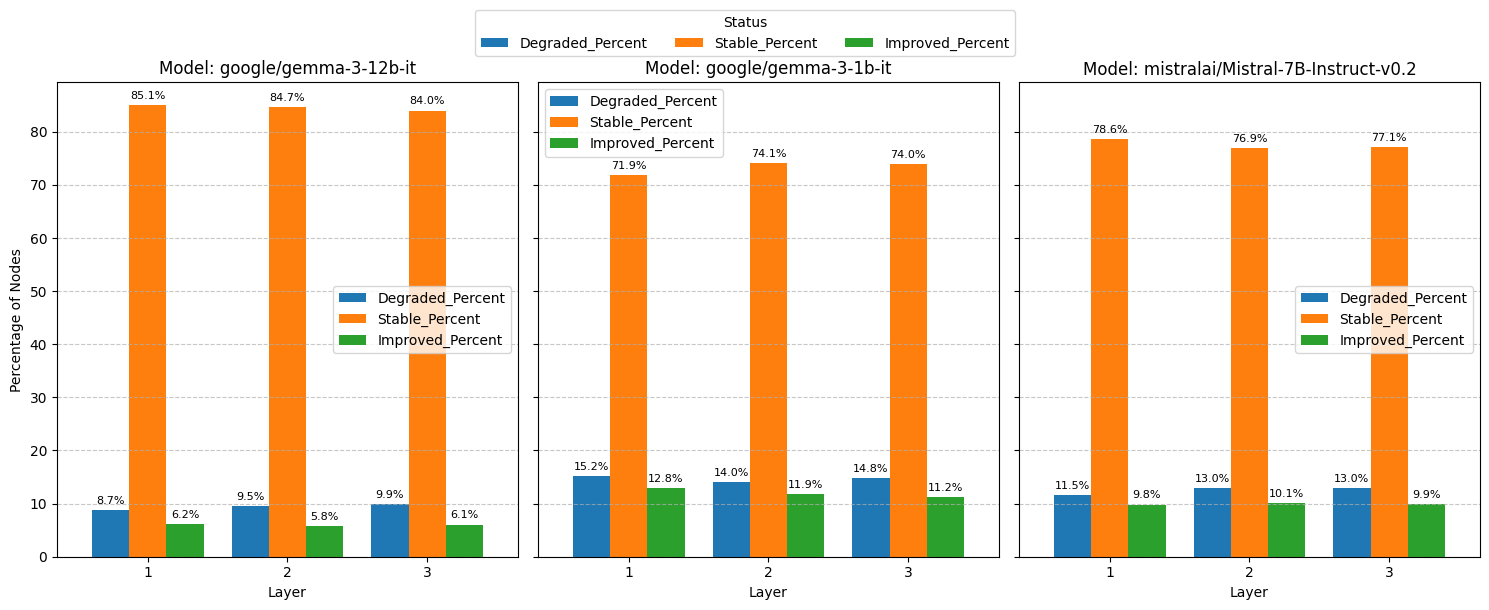

<ipython-input-95-ecad8d30bf2a>:231: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


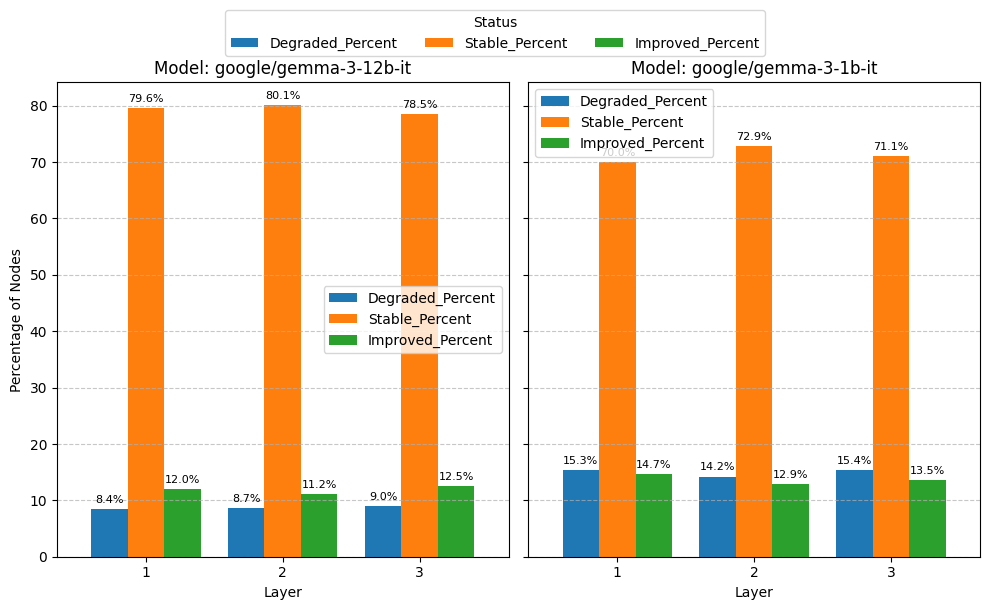

In [ ]:
plot_progression(degraded, stable, improved, para_type='semantic')
plot_progression(degraded, stable, improved, para_type='sg_dialect')

<ipython-input-95-ecad8d30bf2a>:231: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


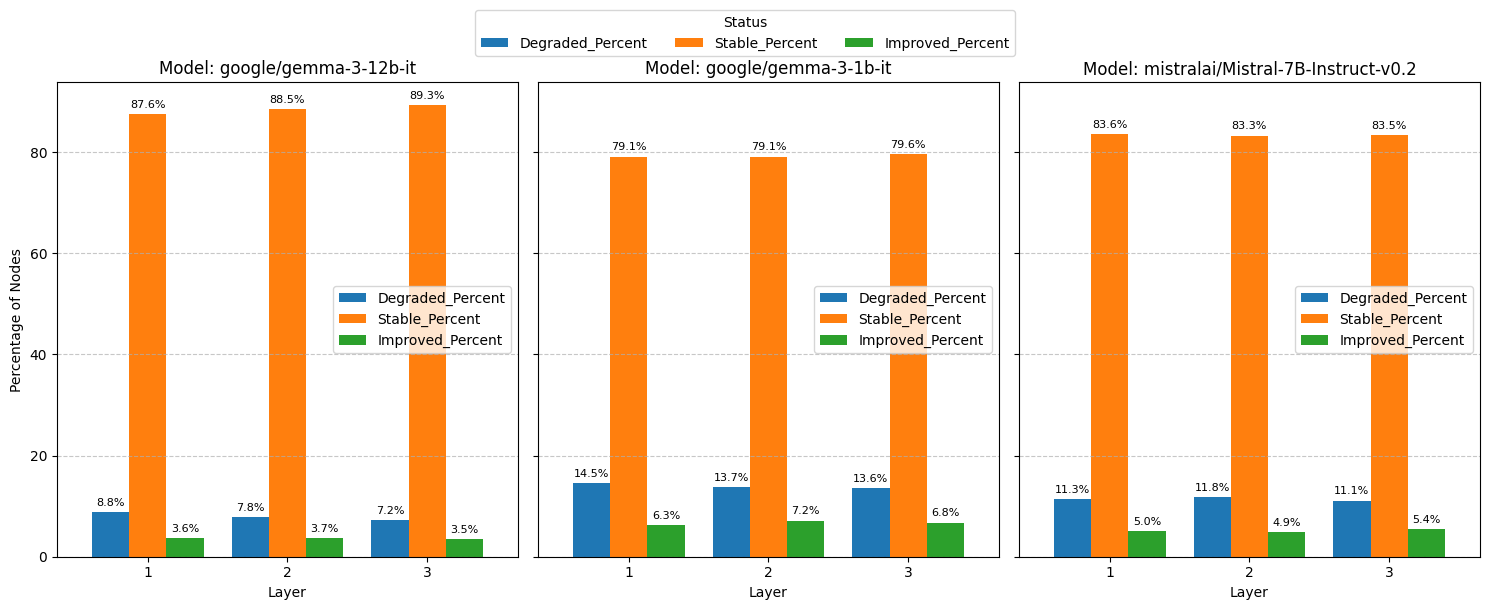

<ipython-input-95-ecad8d30bf2a>:231: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


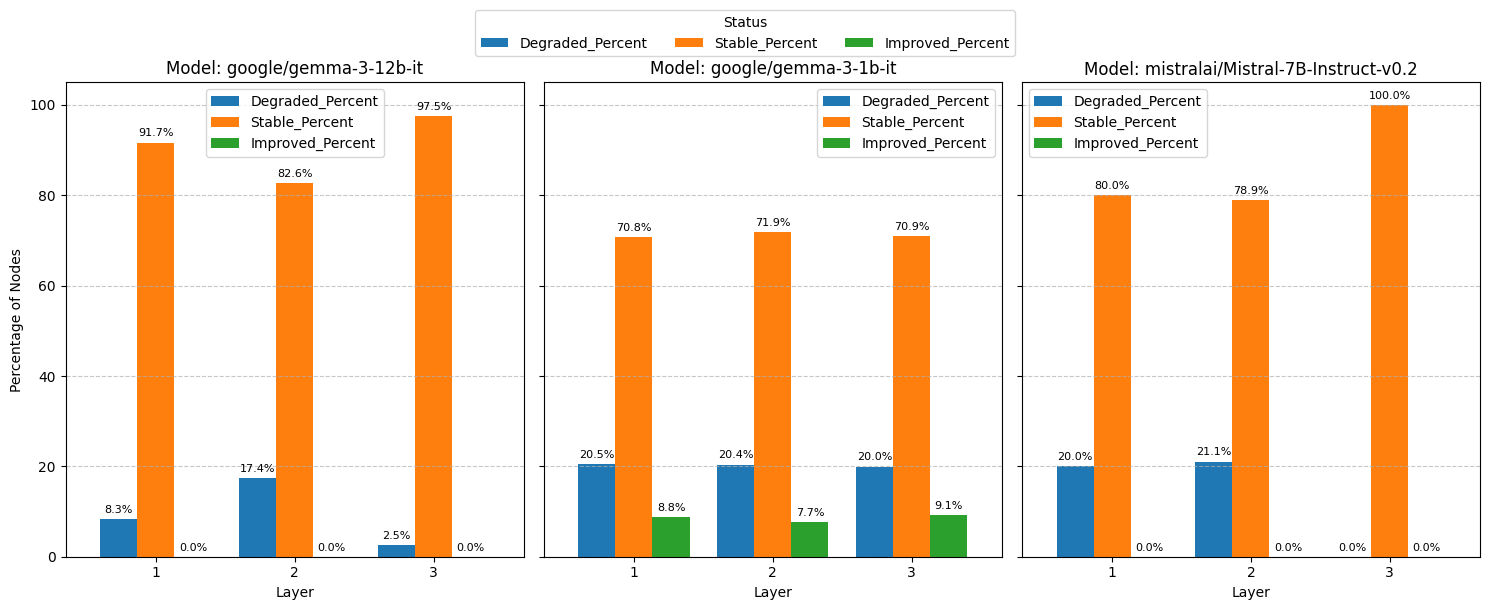

In [191]:
plot_progression(degraded, stable, improved, para_type='semantic')
plot_progression(degraded, stable, improved, para_type='sg_dialect')

In [201]:
summary_pop = agg_df(df_pop)

In [195]:
# 1. Compute the full summary (grouped by gen_modelId, para_type, layer)
summary = agg_df(df_tqa, group_by=['gen_modelId','para_type','layer'])

# 2. Choose the columns you care about
cols = ['rag_em_pct', 'rag_f1_1', 'rag_prec_1', 'rag_rec_1', 'rag_pct']

# 3. Filter by a specific model, e.g. "google/gemma-3-1b-it"
model_name = "google/gemma-3-1b-it"
filtered = summary[summary['gen_modelId'] == model_name]

# 4. Print just the layer + your columns (so you can see them broken out by layer)
print(f"\n=== Metrics for {model_name} ===")
print(filtered[['layer'] + cols].to_string(index=False))



=== Metrics for google/gemma-3-1b-it ===
 layer  rag_em_pct  rag_f1_1  rag_prec_1  rag_rec_1   rag_pct
     0   34.458509  0.114286    0.079520   0.425953 40.084388
     1   36.300310  0.110871    0.077099   0.435969 37.770898
     2   35.936222  0.111388    0.077234   0.434114 38.062142
     3   36.733800  0.107219    0.073209   0.438372 36.449212
     0   29.868228  0.074691    0.050505   0.366667 30.307467
     1   32.400000  0.073603    0.047771   0.398651 29.840000
     2   30.484211  0.073971    0.049669   0.377350 29.642105
     3   31.886665  0.075459    0.050074   0.388891 29.098268


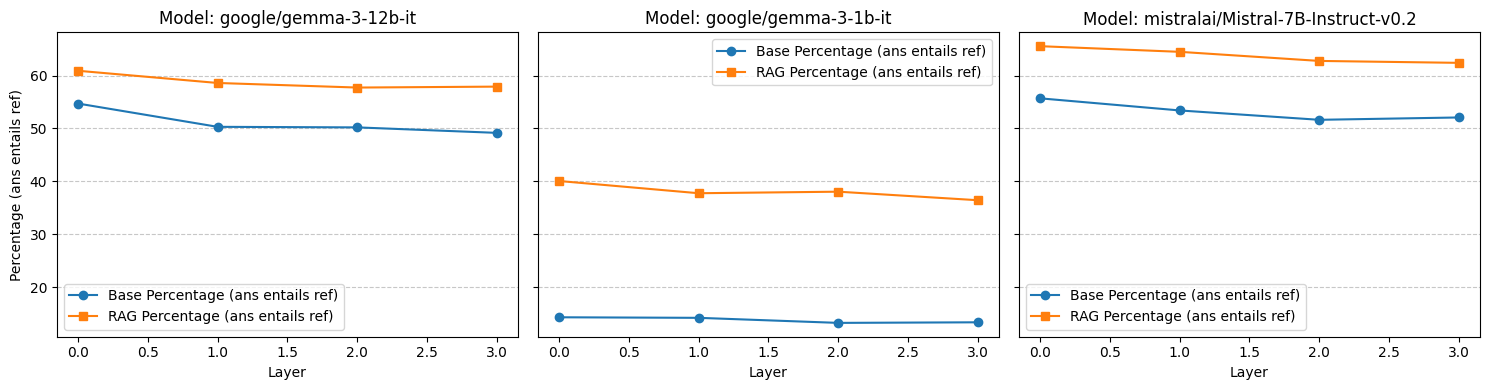

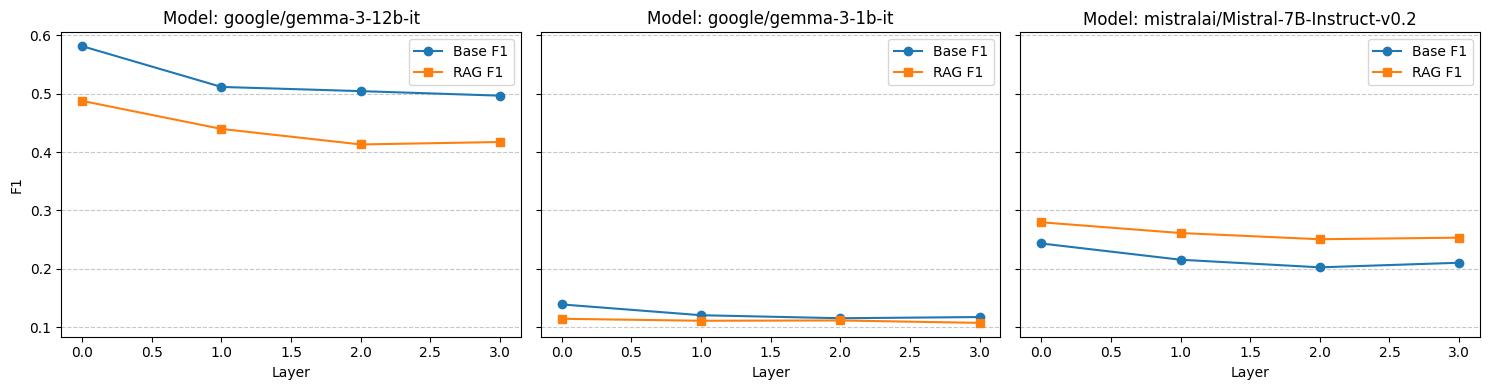

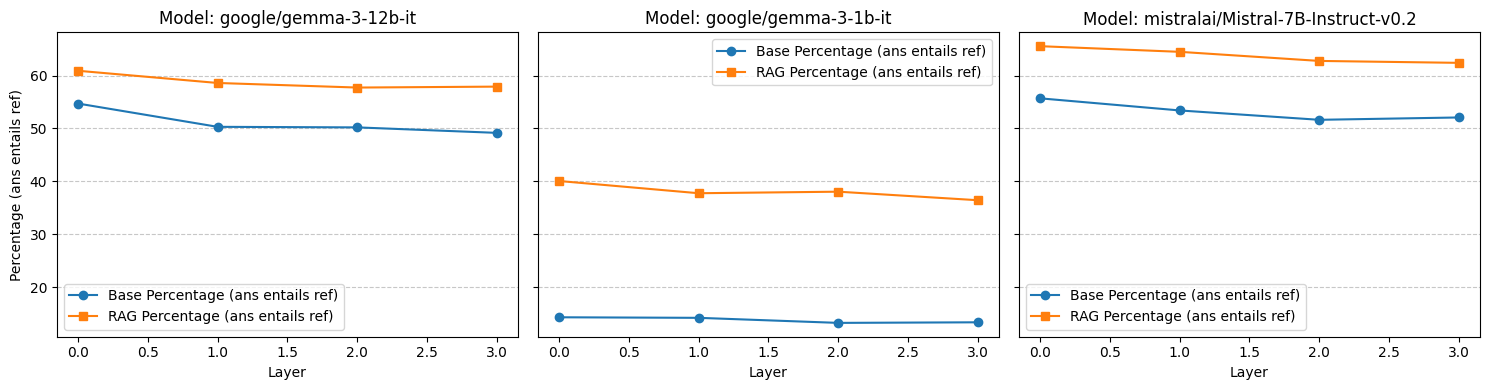

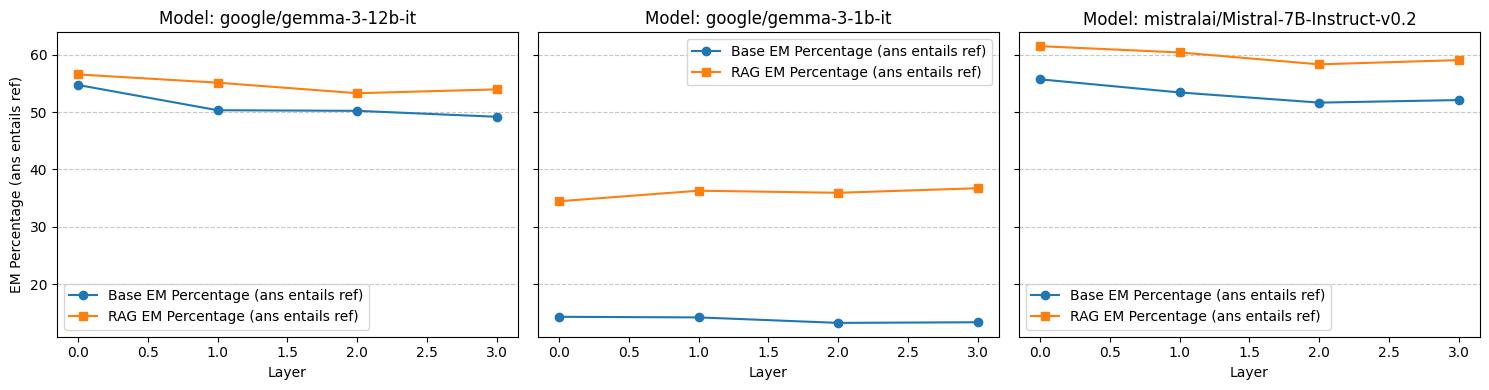

In [ ]:


summary_list = summarise(summary, para_type='semantic')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'f1_1')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'em_pct')

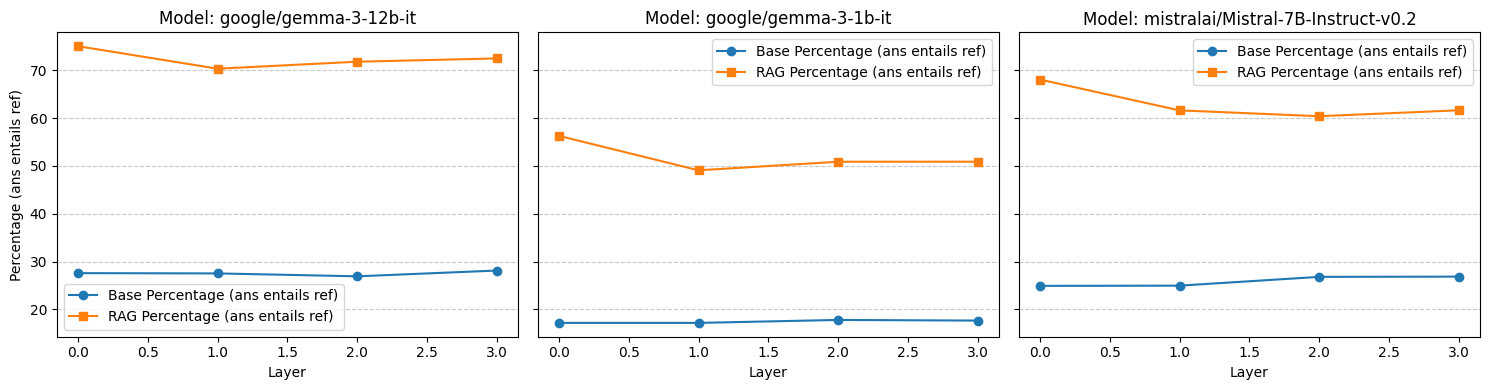

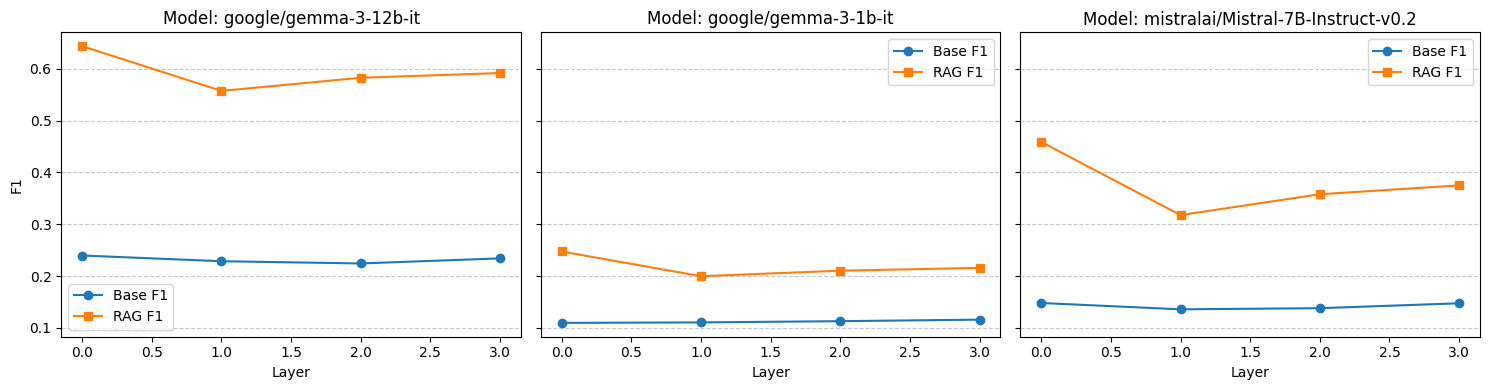

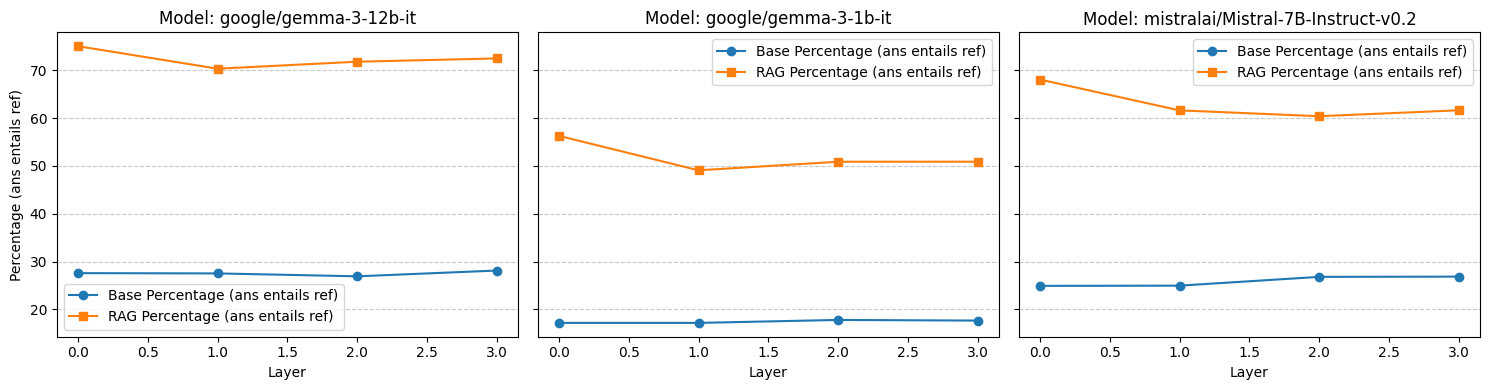

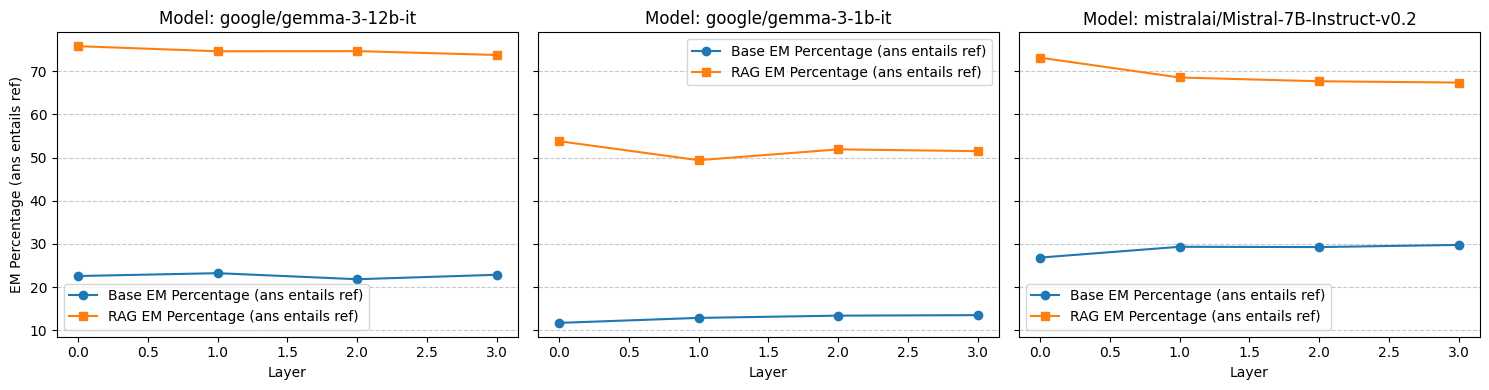

In [203]:
summary_list_pop = summarise(summary_pop, para_type='semantic')
plot_from_summary(summary_list_pop, 'pct')
plot_from_summary(summary_list_pop, 'f1_1')
plot_from_summary(summary_list_pop, 'pct')
plot_from_summary(summary_list_pop, 'em_pct')

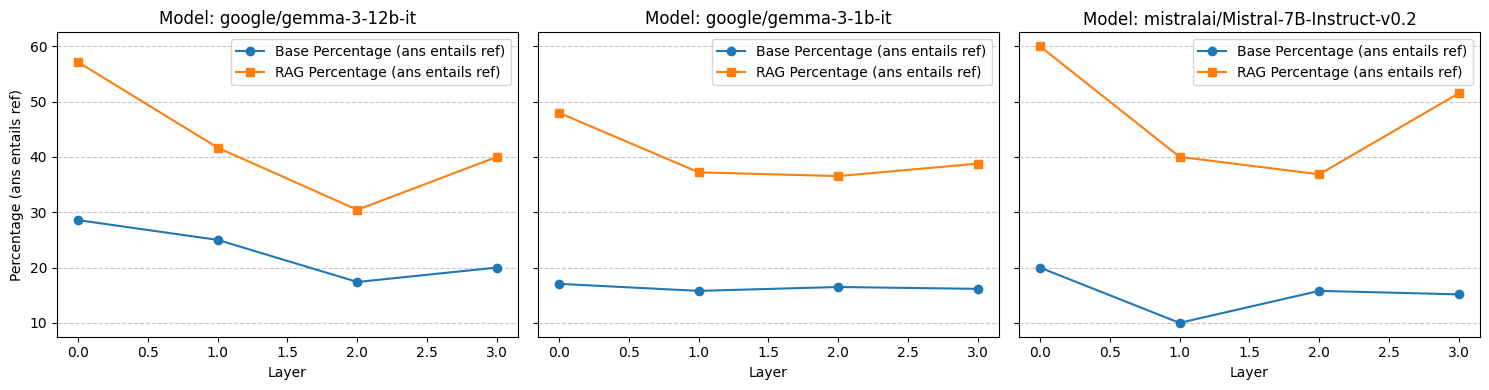

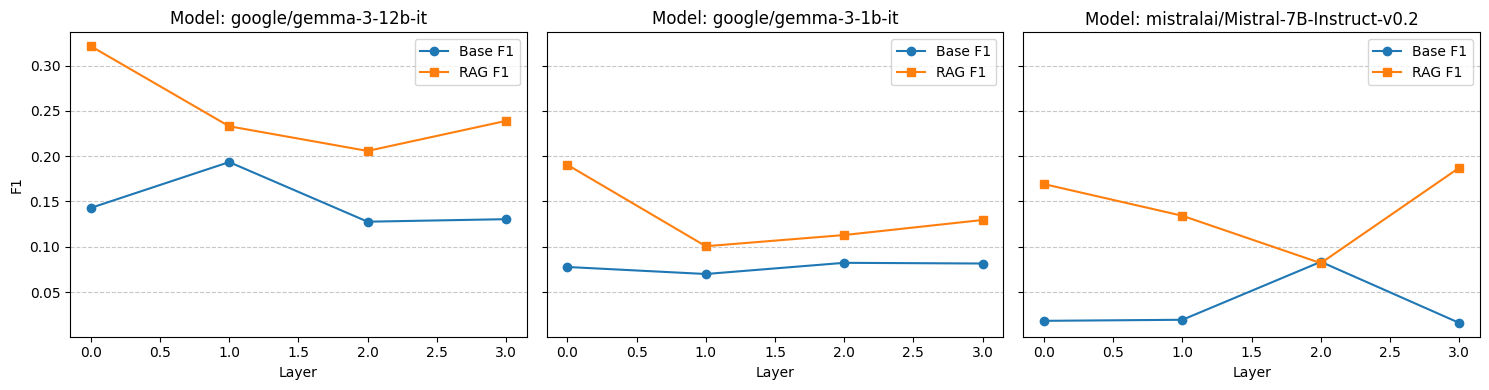

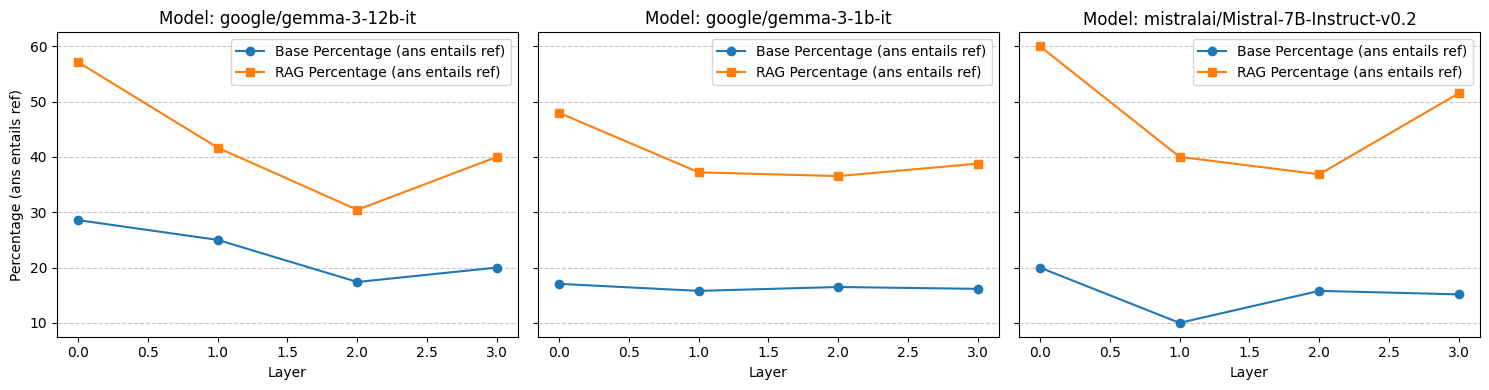

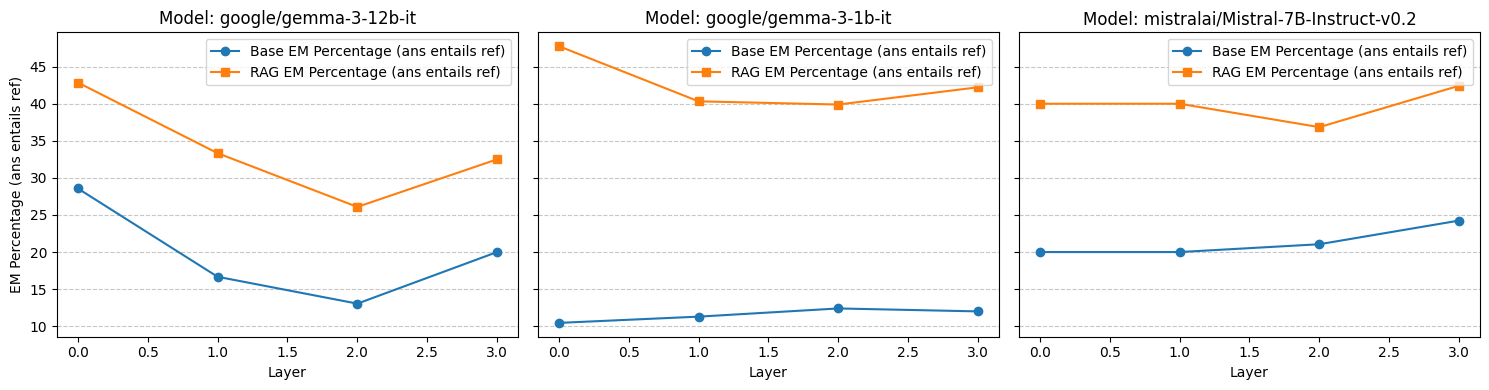

In [204]:
summary_list_pop = summarise(summary_pop, para_type='sg_dialect')
plot_from_summary(summary_list_pop, 'pct')
plot_from_summary(summary_list_pop, 'f1_1')
plot_from_summary(summary_list_pop, 'pct')
plot_from_summary(summary_list_pop, 'em_pct')

# POPQA TQA paraprefix

In [10]:
# load dataset
# df = pd.read_csv('/content/drive/MyDrive/fyp/dataset/TQA-paraphrase_then_prefix-trees-merged.csv')
df_ = pd.read_csv('/homes/lst20/fyp/fyp_resources/LexEval-main/analysis/POPQA-paraphrase_then_prefix-trees.csv')
df_.columns

Index(['Unnamed: 0', 'gen_modelId', 'question_id', 'layer', 'id', 'type',
       'para_type', 'prompt', 'rag_closest_match', 'rag_entities',
       'possible_answers', 'metadata', 'wiki_title', 'rag_found_match',
       'base_found_match', 'base_f1_1', 'base_f1_L', 'rag_f1_1', 'rag_f1_L',
       'base_rec_1', 'base_rec_L', 'rag_rec_1', 'rag_rec_L', 'base_prec_1',
       'base_prec_L', 'rag_prec_1', 'rag_prec_L', 'root_similarity_score',
       'complexity_score', 'fk_score', 'dc_score', 'similarity', 'base',
       'base_rag'],
      dtype='object')

In [11]:
print(df_['para_type'].unique())
valid = {
    'semantic',
    'question_position_suffix',
    'question_position_middle',
    'sg_dialect',
    'question_position_suffix;sg_dialect',
    'question_position_middle;sg_dialect',
}

# Keep only rows where 'para_type' is NOT in the valid set
df = df_[df_['para_type'].isin(valid)]

len(df)

['semantic' 'question_position_suffix' 'question_position_middle'
 'sg_dialect' 'question_position_suffix;sg_dialect'
 'question_position_middle;sg_dialect'
 'sg_dialect;question_position_suffix'
 'sg_dialect;question_position_middle'
 'question_position_suffix;question_position_middle'
 'sg_dialect;question_position_suffix;question_position_middle']


167926

In [42]:
# generate parse tree
correlation(df, em=True, dialect=True)

/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/thinc/shims/pytorch.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self._mixed_precision):


KeyboardInterrupt: 

In [ ]:
import ast

def extract_rules_count(md):
    try:
        # If it's already a dict, just use it; otherwise parse the Python‐literal string
        d = md if isinstance(md, dict) else ast.literal_eval(md or "{}")
        # Grab the "rules" dict (or empty dict if missing) and return its size
        return len(d.get("rules", {}))
    except (ValueError, SyntaxError, TypeError):
        # On any parsing error, fall back to zero
        return 0

# Example usage:
df['num_dialect'] = df['metadata'].apply(extract_rules_count)


0
0
0
0
0
6
5
5
0
0
0
0
11
11
14
0
0
0
0
11
10
10
0
0
0
0
18
16
14
0
0
0
0
18
17
15
0
0
0
0
17
16
16
0
0
0
0
12
12
12
0
0
19
19
17
0
0
0
0
28
26
27
0
0
20
19
22
0
0
18
17
16
0
0
28
32
28
0
0
19
16
17
0
0
30
32
33
0
0
0
8
0
0
11
0
0
2
0
0
33
0
0
26
0
0
0
0
18
38
54
28
19
24
26
0
0
0
0
0
6
5
6
0
0
0
0
18
34
34
0
0
0
0
9
18
17
0
0
0
0
38
39
36
0
0
0
0
24
22
22
0
0
0
0
21
19
14
0
0
0
0
19
16
19
0
0
37
44
42
0
0
44
43
46
0
0
31
31
20
0
0
28
27
27
0
0
36
33
31
0
0
20
27
24
0
0
29
28
24
0
0
28
29
27
0
0
0
10
0
0
16
0
0
13
0
0
29
0
20
0
0
19
0
0
18
34
43
21
25
17
22
0
0
0
0
0
6
0
0
0
0
0
0
0
0
17
0
0
0
0
0
0
0
0
0
0
0
0
17
0
0
0
0
28
0
0
0
0
0
0
0
0
0
0
28
0
0
0
0
38
0
0
25
0
0
0
0
0
4
4
4
0
0
0
0
12
13
13
0
0
0
0
24
24
23
0
0
0
0
14
13
15
0
0
0
0
0
0
0
0
27
26
25
0
0
0
0
34
32
32
0
0
21
19
19
0
0
22
20
21
0
0
0
0
0
0
36
35
36
0
0
32
23
31
0
0
31
34
34
0
0
31
33
32
0
0
0
0
0
8
0
0
0
0
9
0
0
0
0
15
0
0
0
0
12
0
0
0
0
0
0
0
0
19
0
0
0
0
26
0
0
23
0
0
20
0
0
19
0
0
0
0
31
0
0
21
0
0
32
0
0
0
0
0


KeyboardInterrupt: 

In [25]:
nonzero = df.loc[df['num_dialect'] != 0, 'num_dialect']

print(nonzero)


5          6
6          5
7          5
12        11
13        11
          ..
175365    19
175366    26
175376     1
175383     1
175384     1
Name: num_dialect, Length: 49858, dtype: int64


In [26]:
# generate parse tree
df_dialect = df[df['para_type'].str.contains('sg_dialect', na=False)]
correlation(df_dialect, em=True, dialect=True)

/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/thinc/shims/pytorch.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self._mixed_precision):


Skipping constant features: ['dc_score', 'fk_score']
          feature  spearman_rho       p_value
0  ans_word_count     -0.167411  2.684674e-20
1     num_dialect     -0.075246  3.699250e-05
2    q_word_count     -0.051203  5.028913e-03
3         num_ner     -0.048988  7.282239e-03
4  flesch_kincaid     -0.040958  2.487329e-02
5      dale_chall     -0.007376  6.863176e-01


,feature,spearman_rho,p_value
0,ans_word_count,-0.167411,2.684674e-20
1,num_dialect,-0.075246,3.699250e-05
2,q_word_count,-0.051203,5.028913e-03
3,num_ner,-0.048988,7.282239e-03
4,flesch_kincaid,-0.040958,2.487329e-02
5,dale_chall,-0.007376,6.863176e-01


In [45]:
summary = agg_df(df, use_em=True)

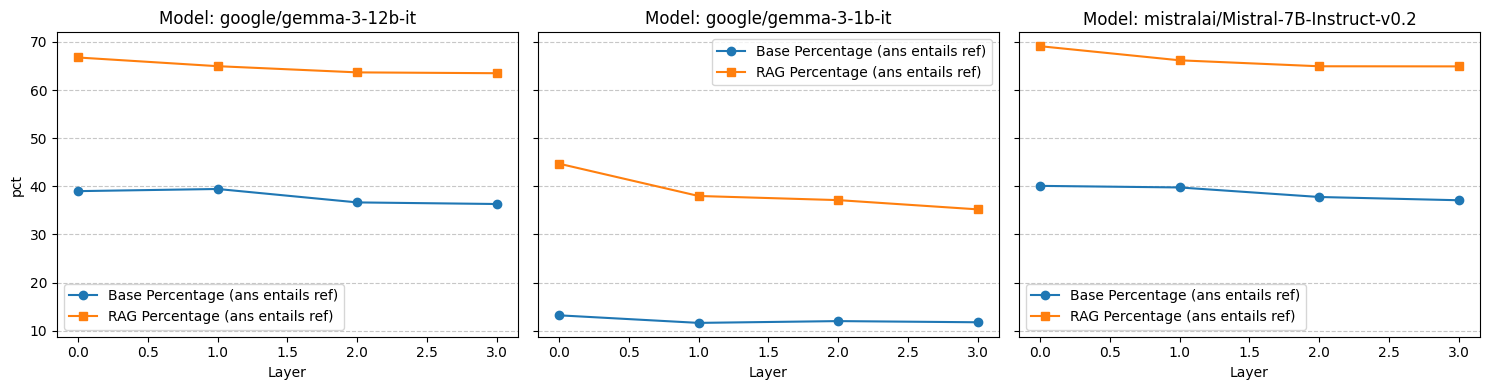

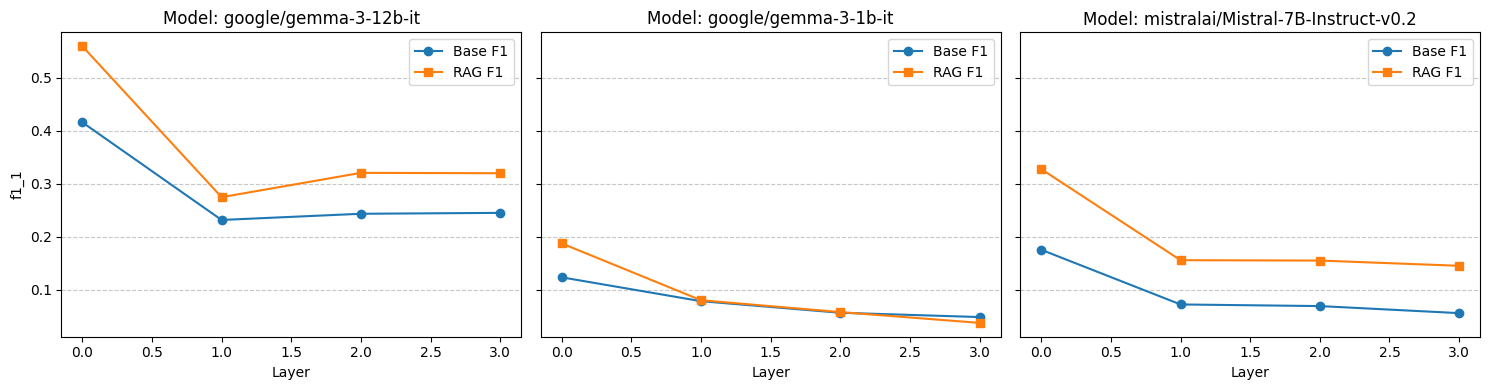

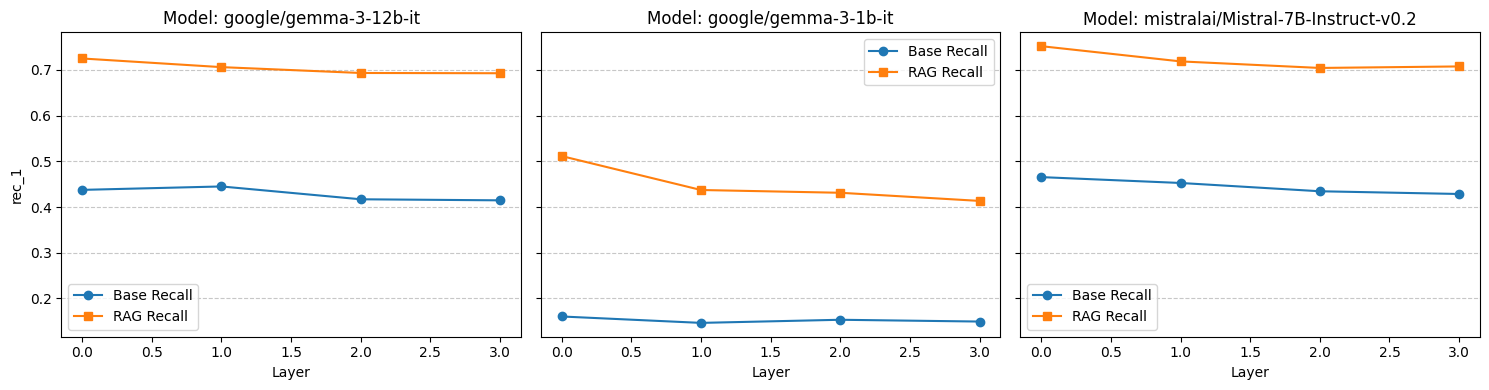

In [47]:
summary_list = summarise(summary, para_type='question_position_middle')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'f1_1')
plot_from_summary(summary_list, 'rec_1')


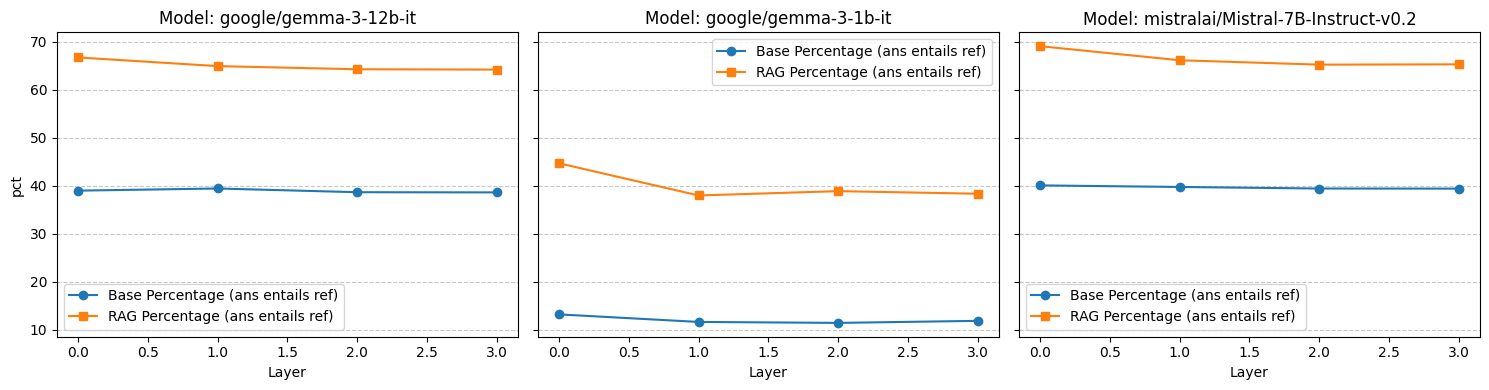

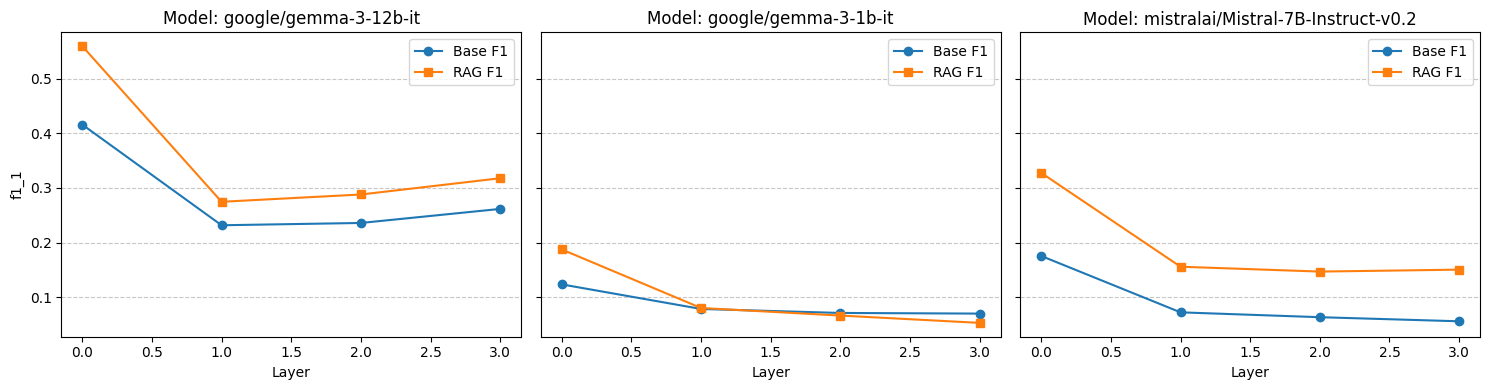

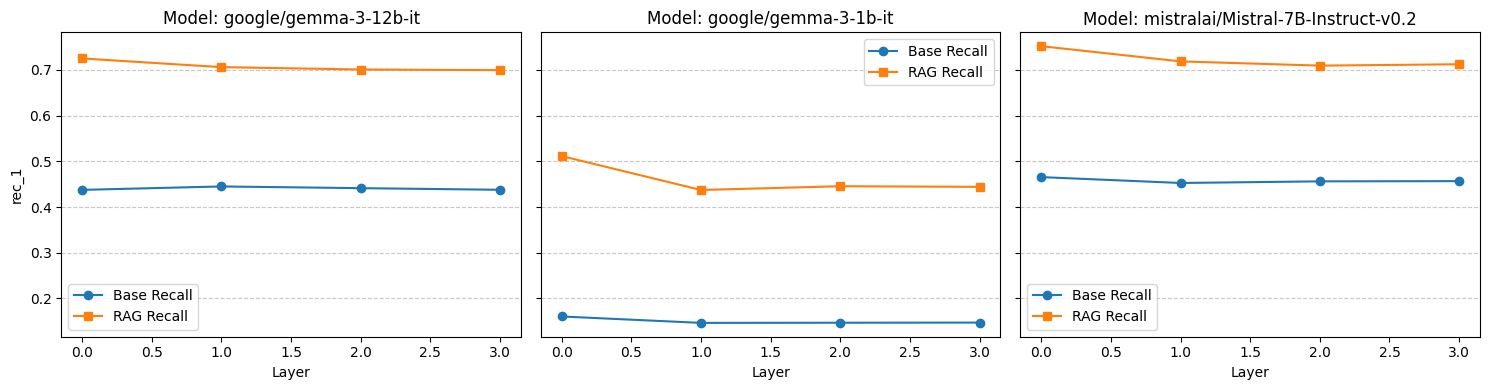

In [49]:
summary_list = summarise(summary, para_type='question_position_suffix')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'f1_1')
plot_from_summary(summary_list, 'rec_1')


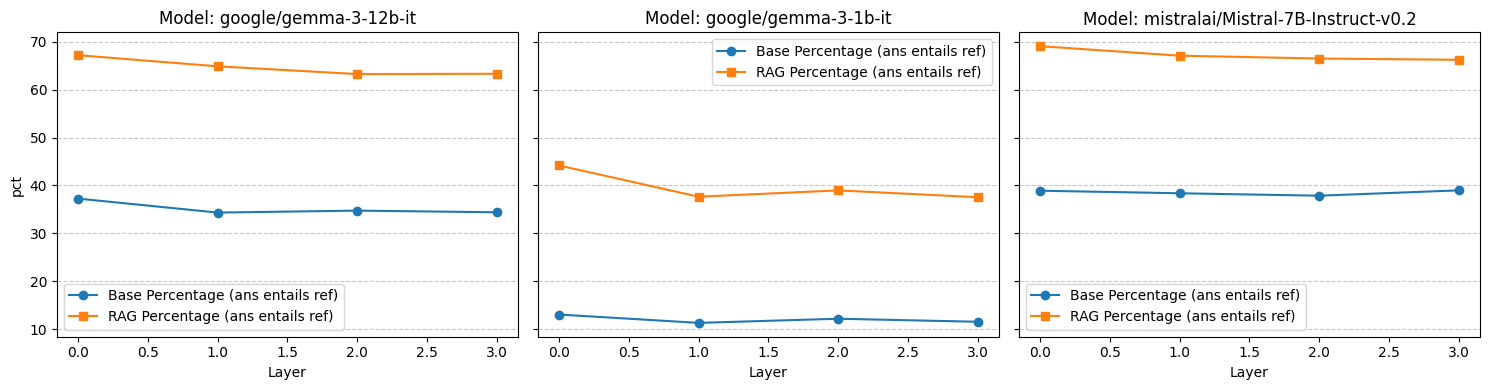

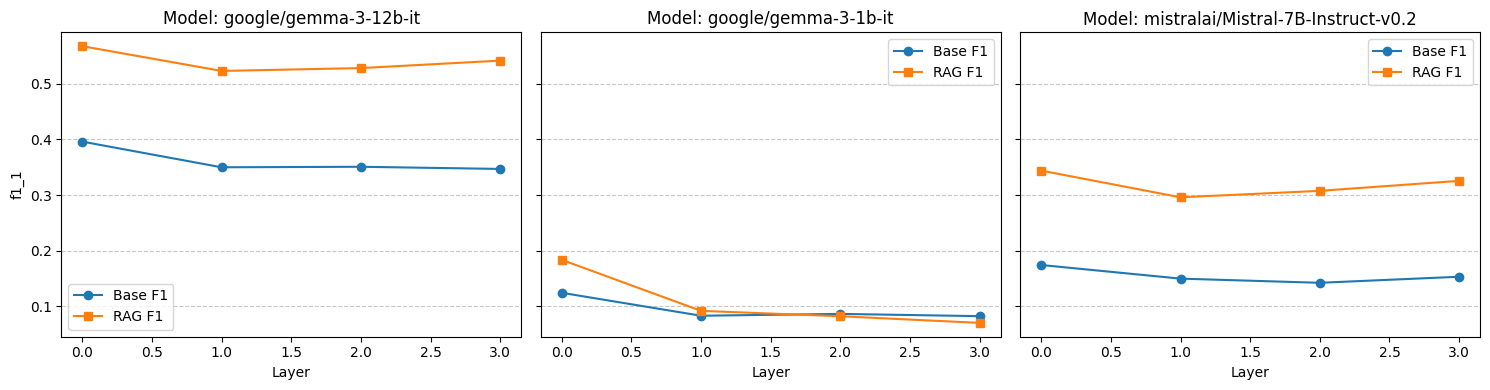

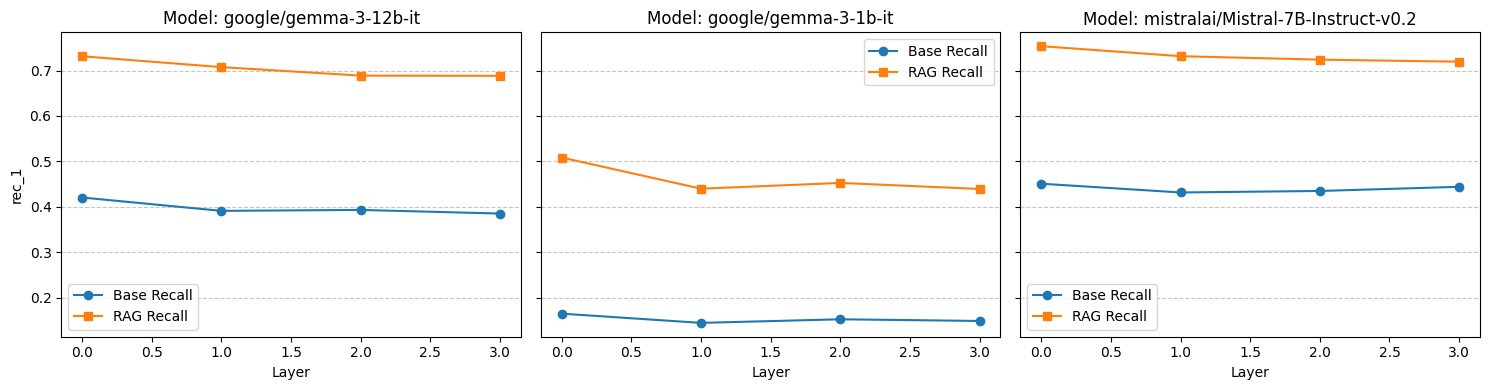

In [51]:
summary_list = summarise(summary, para_type='semantic')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'f1_1')
plot_from_summary(summary_list, 'rec_1')



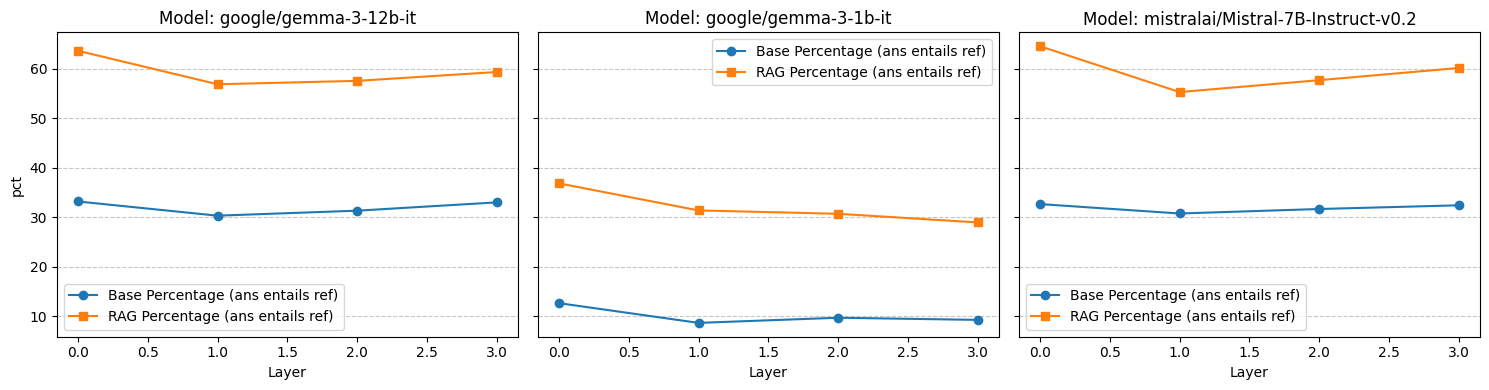

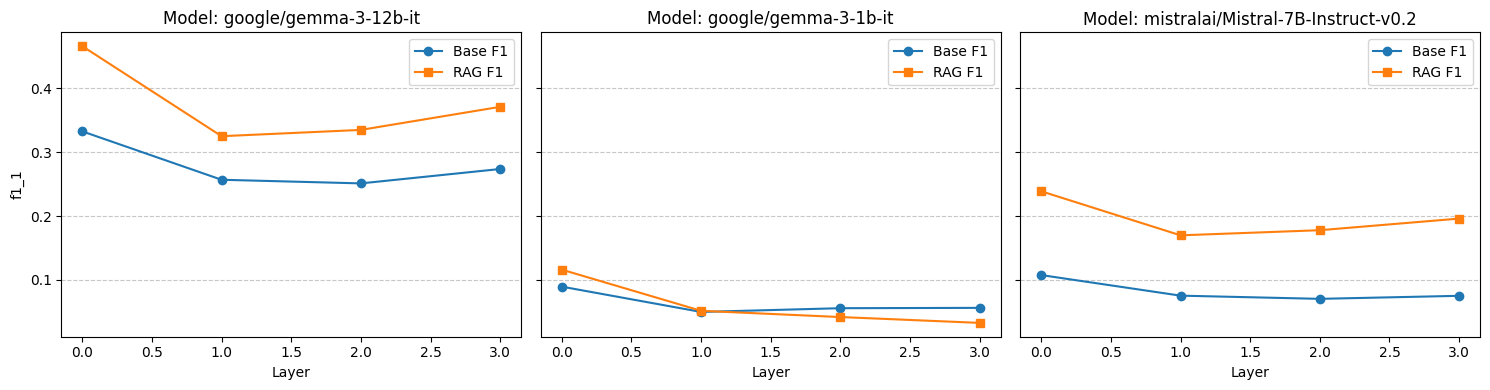

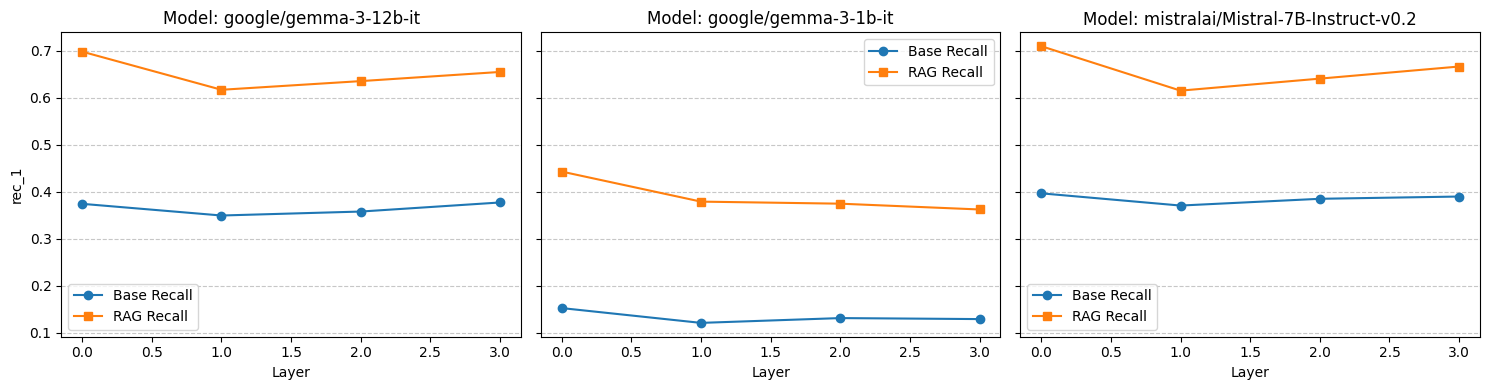

In [53]:
summary_list = summarise(summary, para_type='sg_dialect')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'f1_1')
plot_from_summary(summary_list, 'rec_1')



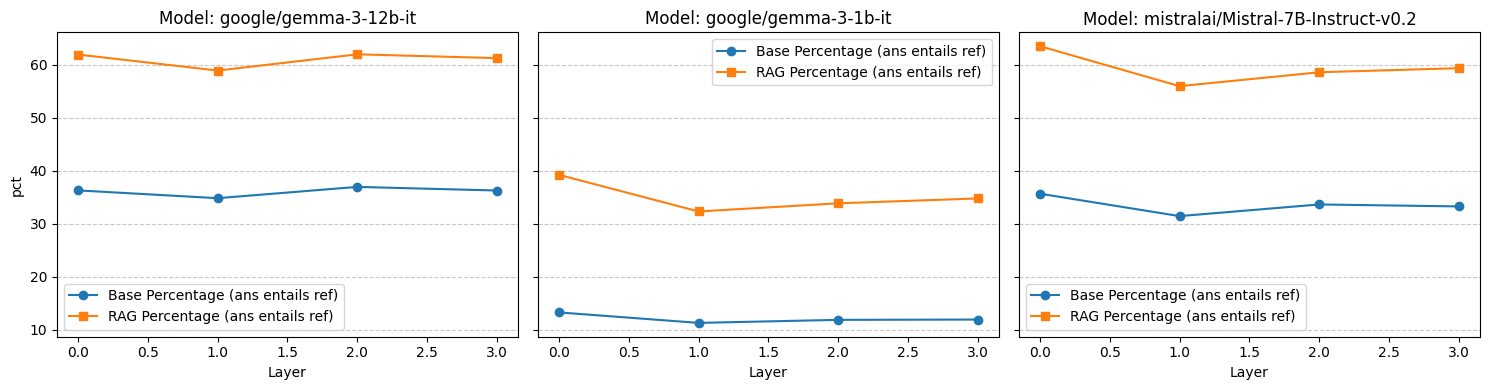

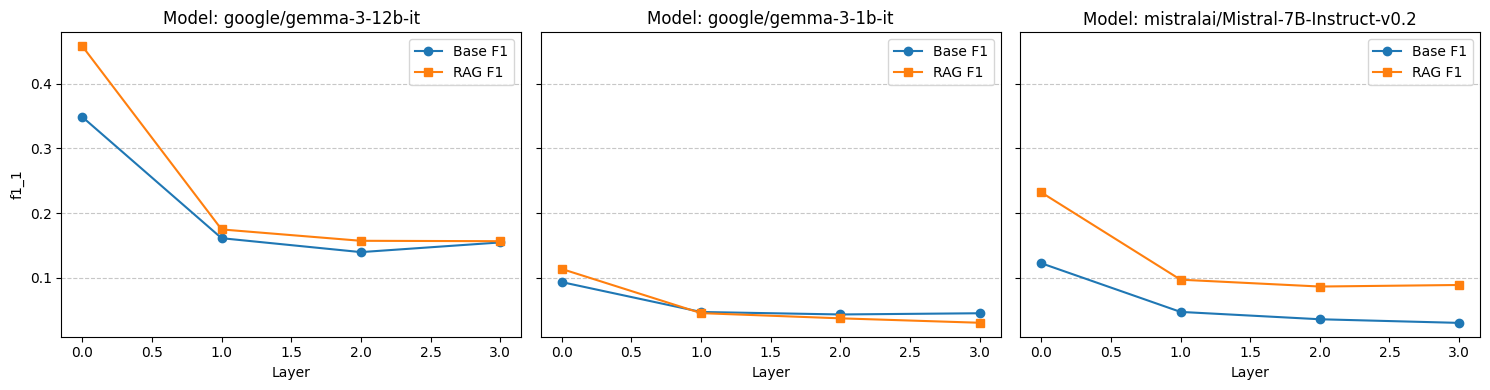

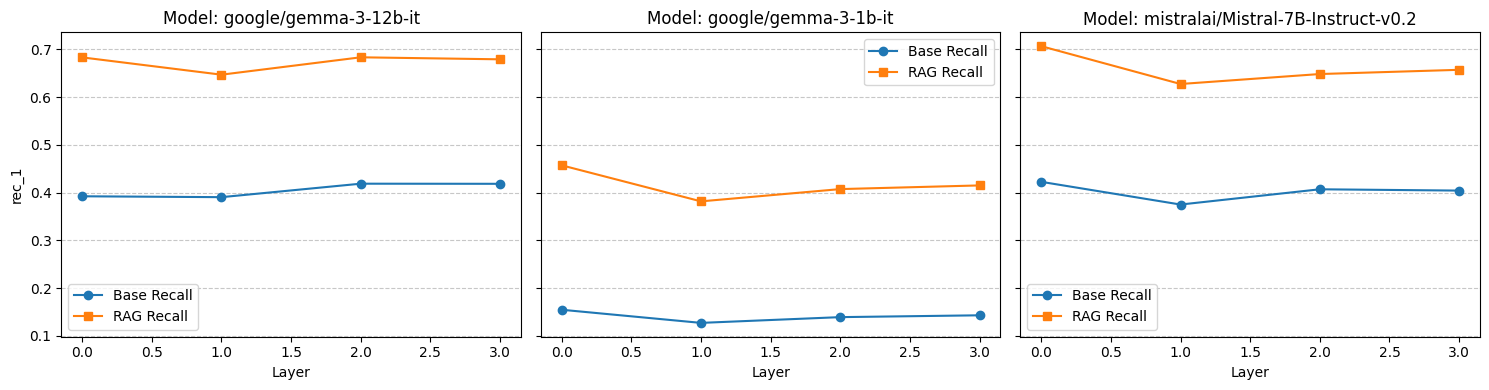

In [55]:
summary_list = summarise(summary, para_type='question_position_suffix;sg_dialect')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'f1_1')
plot_from_summary(summary_list, 'rec_1')



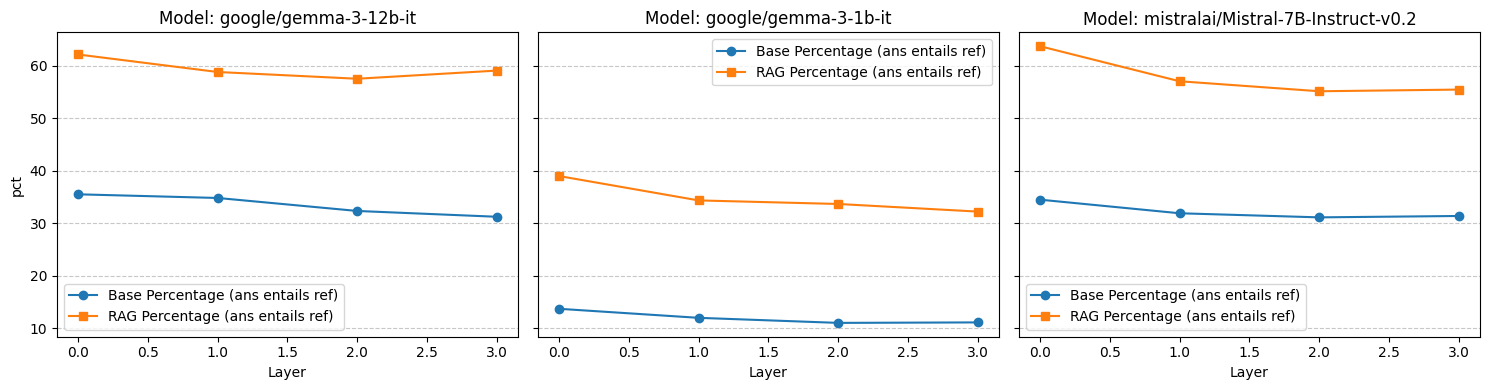

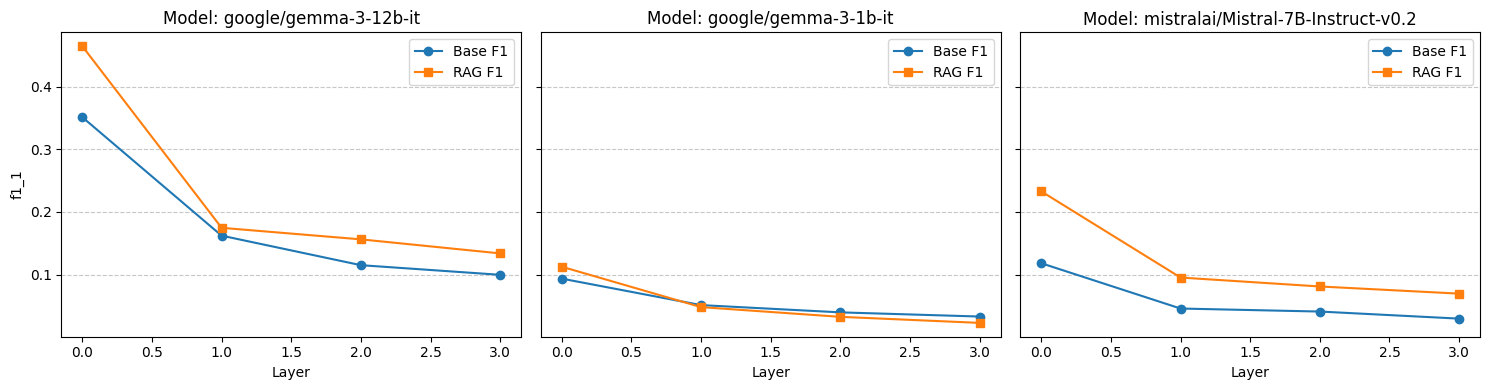

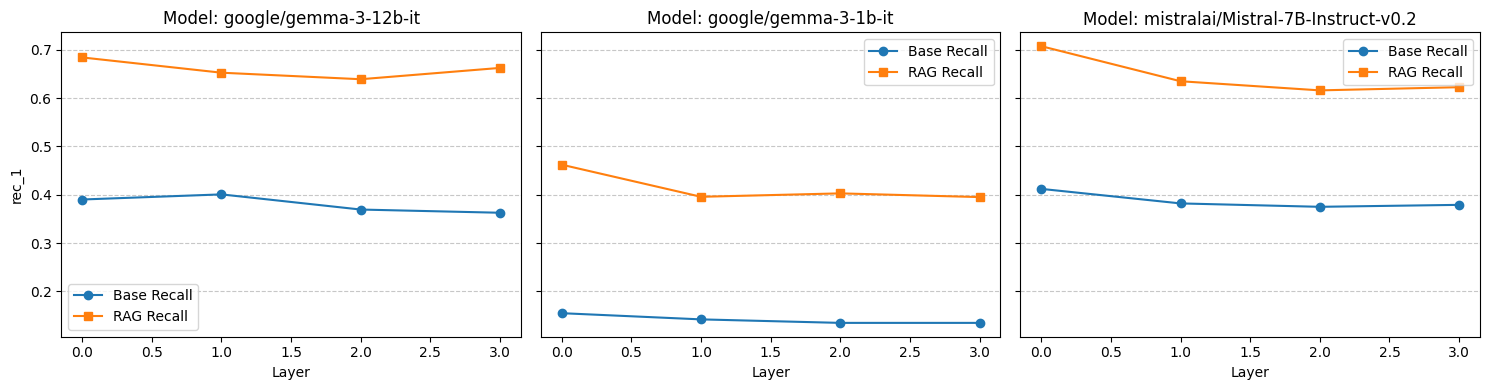

In [56]:
summary_list = summarise(summary, para_type='question_position_middle;sg_dialect')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'f1_1')
plot_from_summary(summary_list, 'rec_1')

In [ ]:
# 1. Compute the full summary (grouped by gen_modelId, para_type, layer)
summary = agg_df(df, group_by=['gen_modelId','para_type','layer'])

# 2. Choose the columns you care about
cols = ['rag_em_pct', 'rag_f1_1', 'rag_prec_1', 'rag_rec_1', 'rag_pct']

# 3. Filter by a specific model, e.g. "google/gemma-3-1b-it"
model_name = "google/gemma-3-1b-it"
filtered = summary[summary['gen_modelId'] == model_name]

# 4. Print just the layer + your columns (so you can see them broken out by layer)
print(f"\n=== Metrics for {model_name} ===")
print(filtered[['layer'] + cols].to_string(index=False))



=== Metrics for google/gemma-3-1b-it ===
 layer  rag_em_pct  rag_f1_1  rag_prec_1  rag_rec_1   rag_pct
     0   36.546185  0.126277    0.088855   0.436613 31.726908
     1   32.745314  0.057750    0.034737   0.390589 24.807056
     2   31.697460  0.036295    0.020376   0.372128 21.189376
     3   30.748007  0.024049    0.013350   0.369186 19.497241
     0   36.546185  0.126277    0.088855   0.436613 31.726908
     1   32.745314  0.057750    0.034737   0.390589 24.807056
     2   33.083141  0.043679    0.025379   0.388323 22.863741
     3   32.709994  0.034542    0.019643   0.391026 21.827100
     0   36.396396  0.123750    0.086516   0.436366 30.990991
     1   34.158416  0.073174    0.044987   0.404144 24.059406
     2   34.267913  0.061401    0.036532   0.407629 21.287643
     3   32.363536  0.050689    0.030210   0.389896 20.753671
     0   30.521092  0.074072    0.047913   0.370070 20.595533
     1   29.135053  0.042504    0.025870   0.351926 17.298938
     2   28.735632  0.031464


# POPQA TQA prefix

In [24]:
# load dataset
df = pd.read_csv('/content/drive/MyDrive/fyp/dataset/POPQA-prefix-trees-merged.csv')
df = merge_identical_base_rag_columns(df)
print(len(df), df.columns)

57287 Index(['question_id', 'gen_modelId', 'layer', 'id', 'type', 'para_type',
       'prompt', 'base_rag_sentences', 'base_rag_entailment_labels',
       'base_rag_entailment_probs', 'num_entailments_base_rag',
       'num_base_rag_sentences', 'best_base_rag_sentence',
       'base_rag_declarative', 'mnli_label_base_rag_to_ref',
       'mnli_probs_base_rag_to_ref', 'base_sentences',
       'base_entailment_labels', 'base_entailment_probs',
       'num_entailments_base', 'num_base_sentences', 'best_base_sentence',
       'base_declarative', 'mnli_label_base_to_ref', 'mnli_probs_base_to_ref',
       'rag_f1_1', 'possible_answers', 'root_similarity_score', 'rag_prec_1',
       'Unnamed: 0', 'reference_ans_declarative', 'dc_score', 'base_rag',
       'similarity', 'base', 'base_found_match', 'root_prompt', 'base_f1_1',
       'rag_entities', 'rag_f1_L', 'rag_closest_match', 'base_prec_L',
       'base_f1_L', 'fk_score', 'rag_rec_1', 'base_rec_1', 'rag_found_match',
       'complexity_scor

In [ ]:
# generate parse tree
corrolation(df)

In [230]:
df['para_type'].unique()

array(['semantic', 'question_position_suffix', 'question_position_middle'],
      dtype=object)

In [232]:
counts_partype = df.groupby(['gen_modelId', 'para_type']).size().reset_index(name='count')
print("\nCounts by gen_modelId and partype:")
counts_partype


Counts by gen_modelId and partype:


,gen_modelId,para_type,count
0,google/gemma-3-12b-it,question_position_middle,1215
1,google/gemma-3-12b-it,question_position_suffix,1215
2,google/gemma-3-12b-it,semantic,10872
3,google/gemma-3-1b-it,question_position_middle,6733
4,google/gemma-3-1b-it,question_position_suffix,6733
5,google/gemma-3-1b-it,semantic,10872
6,mistralai/Mistral-7B-Instruct-v0.2,question_position_middle,5774
7,mistralai/Mistral-7B-Instruct-v0.2,question_position_suffix,5774
8,mistralai/Mistral-7B-Instruct-v0.2,semantic,8099


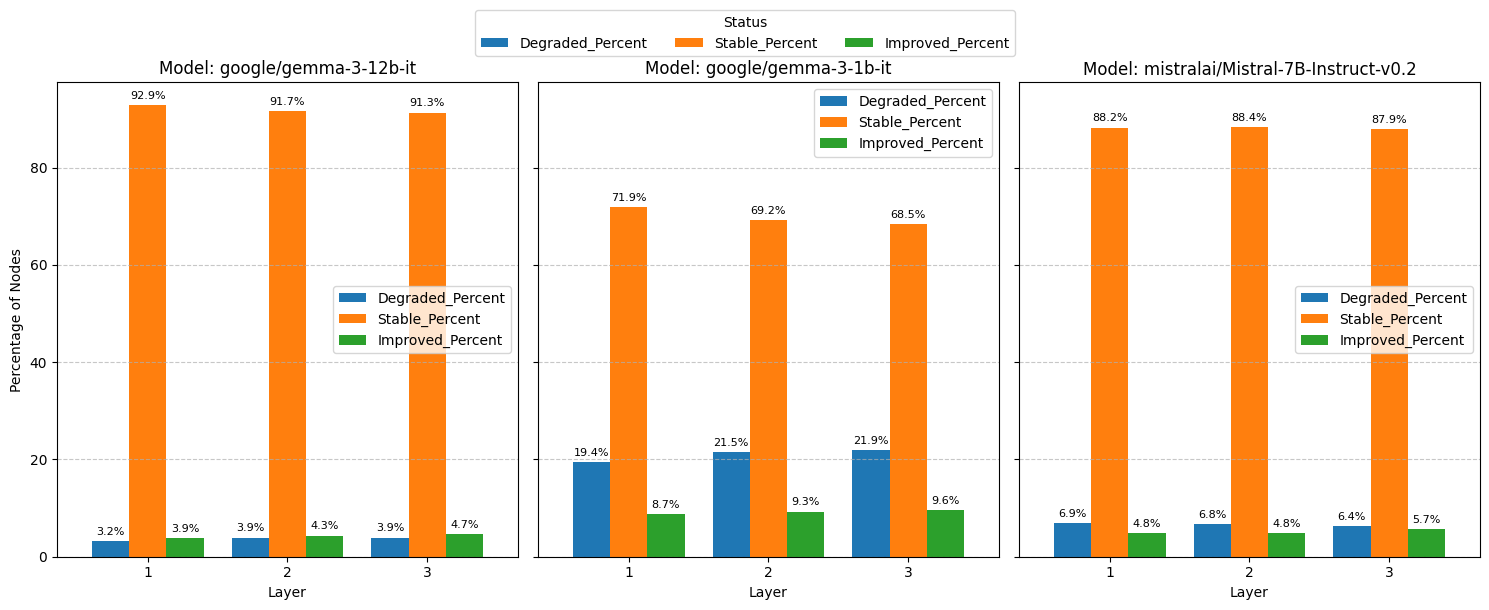

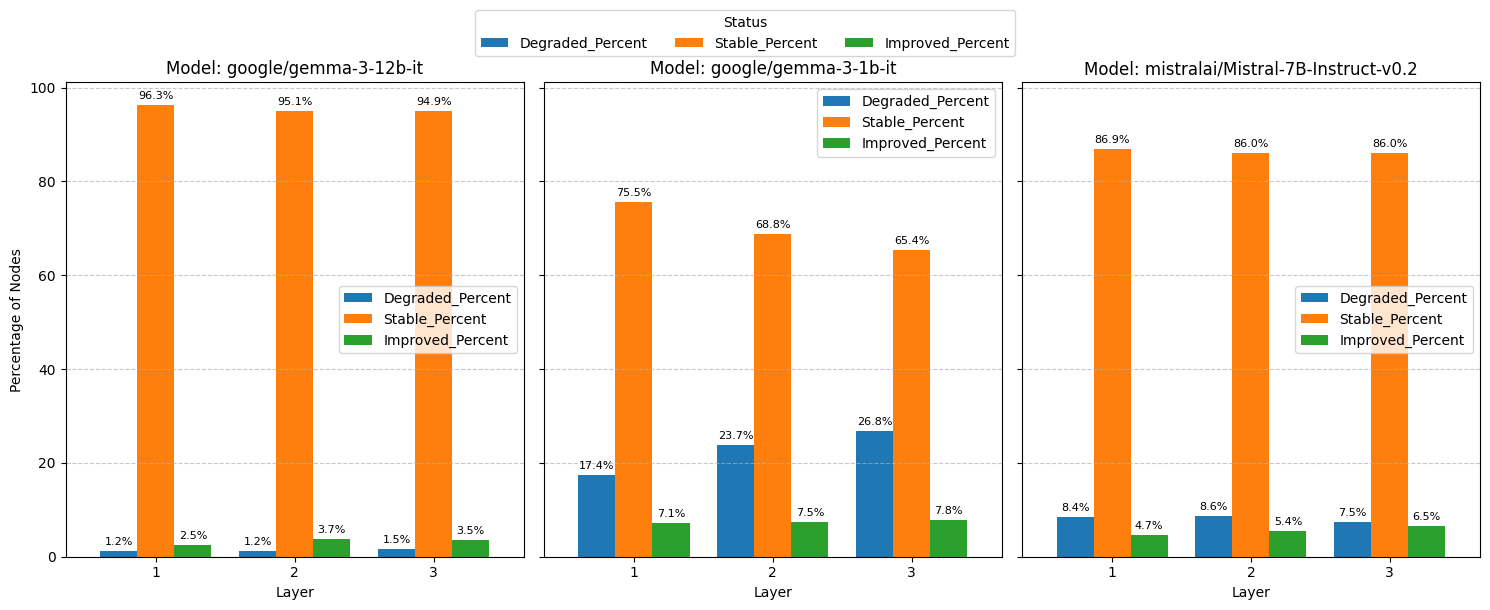

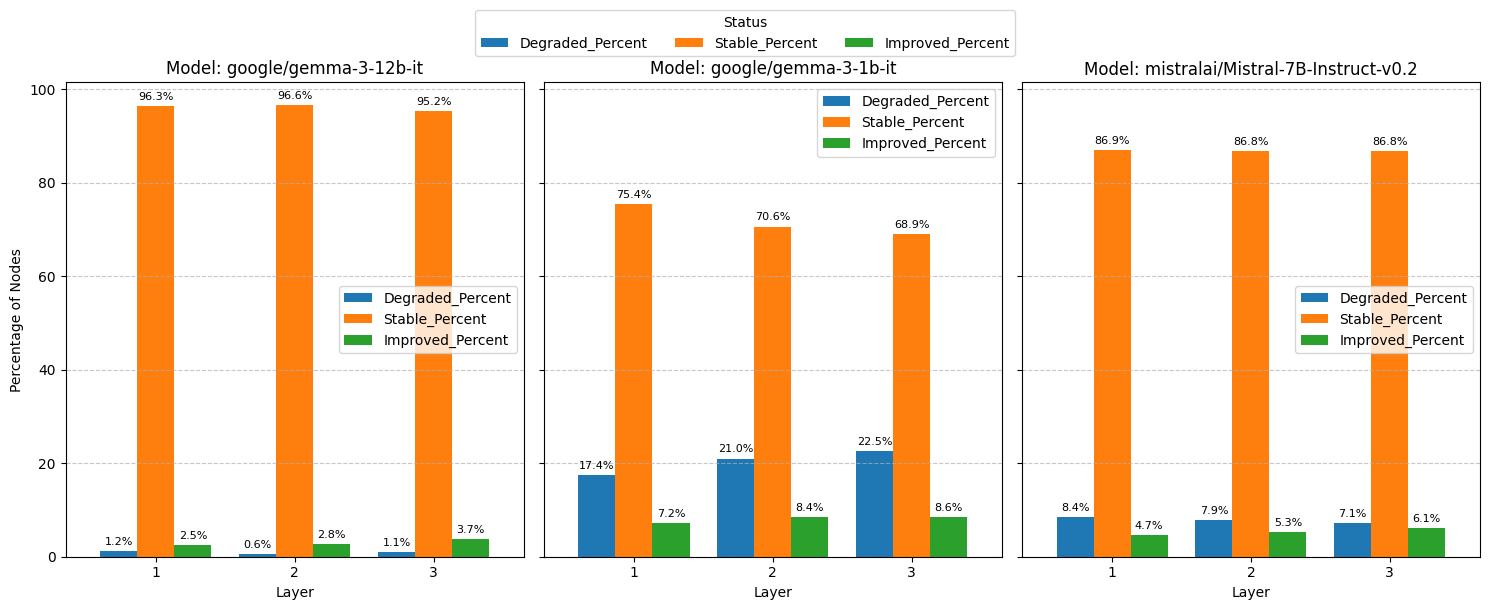

In [244]:
degraded, stable, improved = get_change_status(df)
plot_progression(degraded, stable, improved, para_type='semantic')
plot_progression(degraded, stable, improved, para_type='question_position_middle')
plot_progression(degraded, stable, improved, para_type='question_position_suffix')

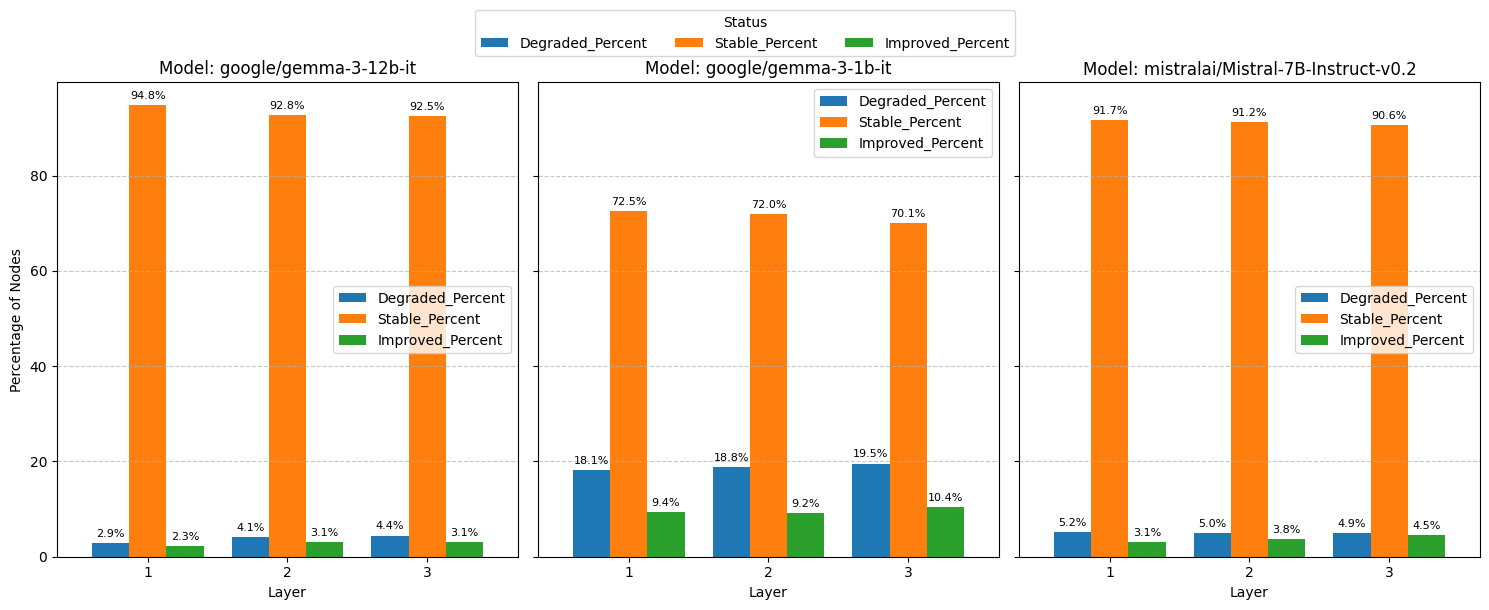

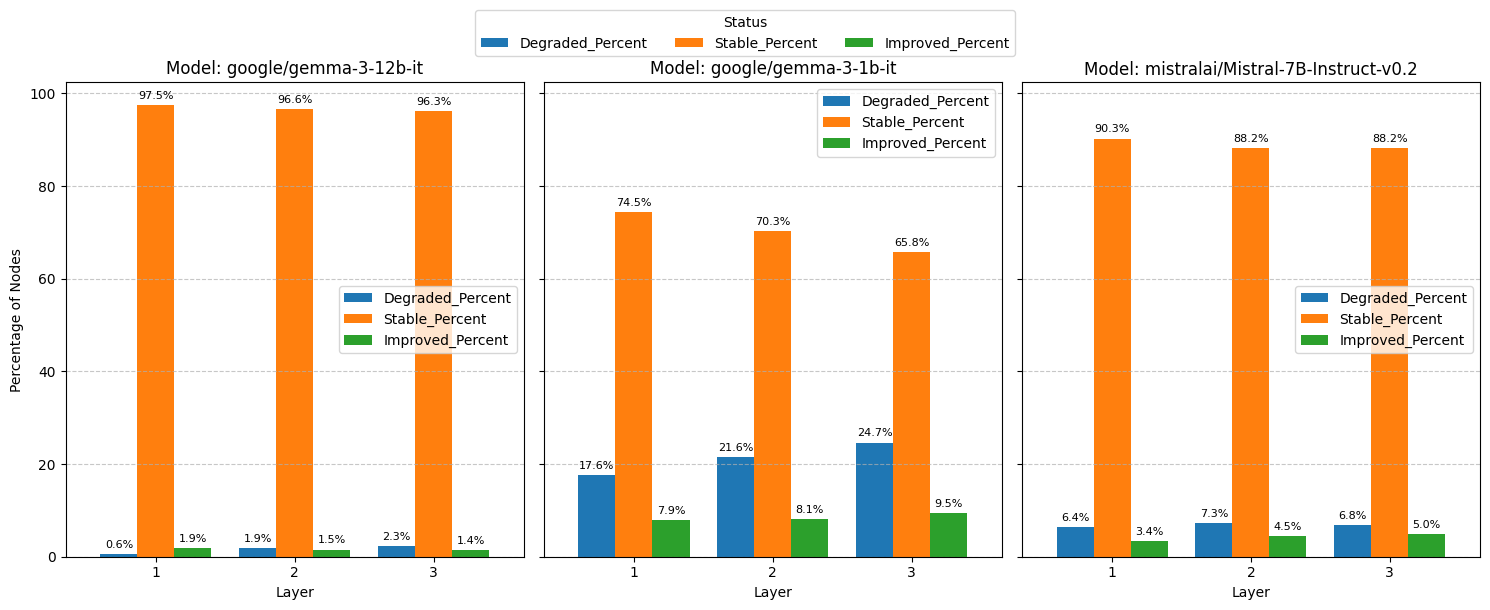

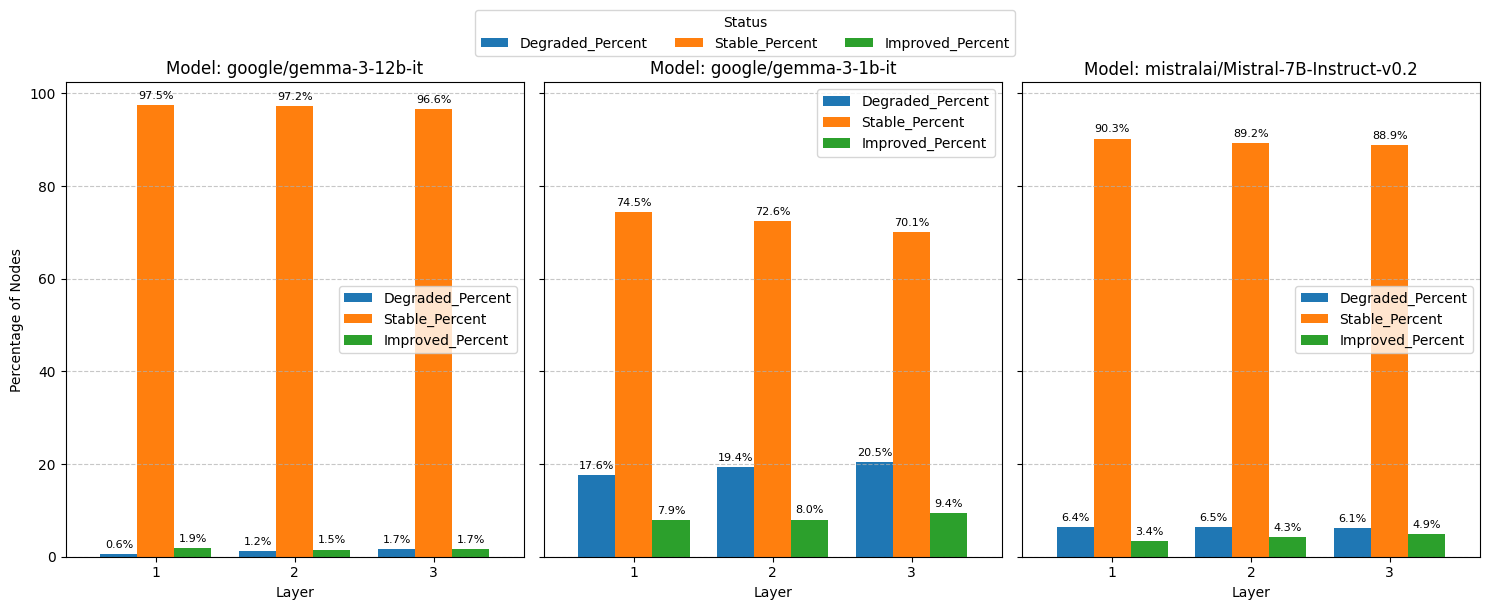

In [245]:
degraded, stable, improved = get_change_status(df, em=True)
plot_progression(degraded, stable, improved, para_type='semantic')
plot_progression(degraded, stable, improved, para_type='question_position_middle')
plot_progression(degraded, stable, improved, para_type='question_position_suffix')

In [246]:
def agg_df(df, group_by=['gen_modelId','para_type','layer']):
    return (
        df.groupby(group_by)
          .agg(
            # Count True/False and percentage for `base_found_match`
            base_true      = ('base_found_match', 'sum'),
            base_false     = ('base_found_match', lambda x: (~x.astype(bool)).sum()),
            base_pct       = ('base_found_match', lambda x: x.mean() * 100),

            # Count True/False and percentage for `rag_found_match`
            rag_em_true    = ('rag_found_match', 'sum'),
            rag_em_false   = ('rag_found_match', lambda x: (~x.astype(bool)).sum()),
            rag_em_pct     = ('rag_found_match', lambda x: x.mean() * 100),

            # Count True/False and percentage for `mnli_label_base_rag_to_ref`
            rag_true  = ('mnli_label_base_rag_to_ref', 'sum'),
            rag_false = ('mnli_label_base_rag_to_ref', lambda x: (~x.astype(bool)).sum()),
            rag_pct   = ('mnli_label_base_rag_to_ref', lambda x: x.mean() * 100),

            # Averages of F1 / recall / precision columns
            base_f1_1      = ('base_f1_1', 'mean'),
            rag_f1_1       = ('rag_f1_1', 'mean'),
            base_f1_L      = ('base_f1_L', 'mean'),
            rag_f1_L       = ('rag_f1_L', 'mean'),
            base_rec_1     = ('base_rec_1', 'mean'),
            rag_rec_1      = ('rag_rec_1', 'mean'),
            base_rec_L     = ('base_rec_L', 'mean'),
            rag_rec_L      = ('rag_rec_L', 'mean'),
            base_prec_1    = ('base_prec_1', 'mean'),
            rag_prec_1     = ('rag_prec_1', 'mean'),
            base_prec_L    = ('base_prec_L', 'mean'),
            rag_prec_L     = ('rag_prec_L', 'mean'),
          )
          .reset_index()
    )

# Example usage:
summary = agg_df(df)
summary

,gen_modelId,para_type,layer,base_true,base_false,base_pct,rag_em_true,rag_em_false,rag_em_pct,rag_true,rag_false,rag_pct,base_f1_1,rag_f1_1,base_f1_L,rag_f1_L,base_rec_1,rag_rec_1,base_rec_L,rag_rec_L,base_prec_1,rag_prec_1,base_prec_L,rag_prec_L
0,google/gemma-3-12b-it,question_position_middle,0,29,52,35.802469,69,12,85.185185,71,10,87.654321,0.330178,0.632375,0.330178,0.632375,0.345679,0.862140,0.345679,0.862140,0.325544,0.582661,0.325544,0.582661
1,google/gemma-3-12b-it,question_position_middle,1,63,99,38.888889,140,22,86.419753,144,18,88.888889,0.271875,0.418110,0.271875,0.416085,0.378807,0.867490,0.378807,0.867490,0.254168,0.364895,0.254168,0.363463
2,google/gemma-3-12b-it,question_position_middle,2,124,200,38.271605,275,49,84.876543,292,32,90.123457,0.290726,0.484002,0.290726,0.481968,0.361728,0.870885,0.361728,0.870885,0.275832,0.425855,0.275832,0.424267
3,google/gemma-3-12b-it,question_position_middle,3,269,379,41.512346,546,102,84.259259,581,67,89.660494,0.326317,0.477490,0.325906,0.475898,0.383745,0.867078,0.383745,0.866049,0.315494,0.427673,0.315214,0.426638
4,google/gemma-3-12b-it,question_position_suffix,0,29,52,35.802469,69,12,85.185185,71,10,87.654321,0.330178,0.632375,0.330178,0.632375,0.345679,0.862140,0.345679,0.862140,0.325544,0.582661,0.325544,0.582661
5,google/gemma-3-12b-it,question_position_suffix,1,63,99,38.888889,140,22,86.419753,144,18,88.888889,0.271875,0.418110,0.271875,0.416085,0.378807,0.867490,0.378807,0.867490,0.254168,0.364895,0.254168,0.363463
6,google/gemma-3-12b-it,question_position_suffix,2,134,190,41.358025,277,47,85.493827,291,33,89.814815,0.308530,0.439312,0.307708,0.435700,0.395679,0.873560,0.395532,0.873560,0.294710,0.386620,0.294042,0.383861
7,google/gemma-3-12b-it,question_position_suffix,3,277,371,42.746914,552,96,85.185185,585,63,90.277778,0.326477,0.435150,0.325984,0.432303,0.400514,0.864506,0.400257,0.864506,0.315108,0.385400,0.314728,0.383595
8,google/gemma-3-12b-it,semantic,0,162,563,22.344828,553,172,76.275862,559,166,77.103448,0.240748,0.654107,0.240321,0.653134,0.256253,0.820211,0.256023,0.819751,0.241725,0.616895,0.241104,0.615993
9,google/gemma-3-12b-it,semantic,1,308,1142,21.241379,1097,353,75.655172,1127,323,77.724138,0.229825,0.664290,0.229287,0.663957,0.244103,0.820659,0.243644,0.819969,0.231496,0.628766,0.230818,0.628538


In [247]:
# 1. Compute the full summary (grouped by gen_modelId, para_type, layer)
summary = agg_df(df, group_by=['gen_modelId','para_type','layer'])

# 2. Choose the columns you care about
cols = ['rag_em_pct', 'rag_f1_1', 'rag_prec_1', 'rag_rec_1', 'rag_pct']

# 3. Filter by a specific model, e.g. "google/gemma-3-1b-it"
model_name = "google/gemma-3-1b-it"
filtered = summary[summary['gen_modelId'] == model_name]

# 4. Print just the layer + your columns (so you can see them broken out by layer)
print(f"\n=== Metrics for {model_name} ===")
print(filtered[['layer'] + cols].to_string(index=False))



=== Metrics for google/gemma-3-1b-it ===
 layer  rag_em_pct  rag_f1_1  rag_prec_1  rag_rec_1   rag_pct
     0   59.465479  0.271964    0.197829   0.653304 60.579065
     1   49.777283  0.144745    0.094003   0.543615 50.334076
     2   45.935412  0.100510    0.062507   0.515256 44.320713
     3   44.289694  0.067077    0.040851   0.497488 41.532033
     0   59.242762  0.272023    0.197875   0.650520 60.579065
     1   49.554566  0.143893    0.093485   0.543059 50.445434
     2   47.828508  0.104081    0.065020   0.532192 47.995546
     3   48.050139  0.081772    0.050179   0.530757 46.601671
     0   56.413793  0.265910    0.194035   0.631019 59.034483
     1   47.655172  0.164968    0.108705   0.534866 48.275862
     2   46.896552  0.137164    0.086480   0.529307 46.793103
     3   47.214076  0.123977    0.077482   0.531407 46.713817


In [275]:
# Usage:
degraded, stable, improved = get_change_status(df)

deg_sample = sample_against_root(df, degraded, sample_size=30)
stab_sample = sample_against_root(df, stable,   sample_size=5)
imp_sample  = sample_against_root(df, improved, sample_size=5)

print("=== Degraded vs Root ===")
for _, row in deg_sample.iterrows():
    print(f"question_id:    {row['question_id']}")
    print(f"child_prompt:   {row['child_prompt']}")
    print(f"child_response: {row['child_response']}")
    print(f"root_prompt:    {row['root_prompt']}")
    print(f"root_response:  {row['root_response']}")
    print(f"possible answers:  {row['possible_answers']}")
    print(f"reference_ans_declarative:  {row['reference_ans_declarative']}")
    print(f"base_rag_declarative:  {row['base_rag_declarative']}")
    print(f"mnli_label_base_rag_to_ref:  {row['mnli_label_base_rag_to_ref']}")
    print(f"root_mnli_label:  {row['root_mnli_label']}")
    print(f"root_gen: {row['root_gen']}")
    print("-" * 40)

print("\n=== Stable vs Root ===")
for _, row in stab_sample.iterrows():
    print(f"question_id:    {row['question_id']}")
    print(f"child_prompt:   {row['child_prompt']}")
    print(f"child_response: {row['child_response']}")
    print(f"root_prompt:    {row['root_prompt']}")
    print(f"root_response:  {row['root_response']}")
    print(f"possible answers:  {row['possible_answers']}")
    print(f"reference_ans_declarative:  {row['reference_ans_declarative']}")
    print(f"base_rag_declarative:  {row['base_rag_declarative']}")
    print(f"mnli_label_base_rag_to_ref:  {row['mnli_label_base_rag_to_ref']}")
    print(f"root_mnli_label:  {row['root_mnli_label']}")
    print("-" * 40)

print("\n=== Improved vs Root ===")
for _, row in imp_sample.iterrows():
    print(f"question_id:    {row['question_id']}")
    print(f"child_prompt:   {row['child_prompt']}")
    print(f"child_response: {row['child_response']}")
    print(f"root_prompt:    {row['root_prompt']}")
    print(f"root_response:  {row['root_response']}")
    print(f"possible answers:  {row['possible_answers']}")
    print(f"reference_ans_declarative:  {row['reference_ans_declarative']}")
    print(f"base_rag_declarative:  {row['base_rag_declarative']}")
    print(f"mnli_label_base_rag_to_ref:  {row['mnli_label_base_rag_to_ref']}")
    print(f"root_mnli_label:  {row['root_mnli_label']}")
    print("-" * 40)

=== Degraded vs Root ===
question_id:    3910
child_prompt:   == References == Several yet later disciples, such as Zillig, the Catalan Gerhard, the Transylvanian Hannenheim and the Greek Skalkottas, are sometimes covered by the term, though (apart from Gerhard) they never studied in Vienna but as part of Schoenberg's masterclass in Berlin. The proclamation however, did not include a pardon. Who was the composer of There Will Be Blood?
child_response: Daniel Plainview (Day-Lewis).
root_prompt:    Who was the composer of There Will Be Blood?
root_response:  Jonny Greenwood composed the music for There Will Be Blood.
possible answers:  ['Jonny Greenwood', 'Jonathan Richard Guy Greenwood']
reference_ans_declarative:  Jonny Greenwood was the composer of There Will Be Blood.
base_rag_declarative:  Daniel Plainview (Day-Lewis) was the composer of There Will Be Blood.
mnli_label_base_rag_to_ref:  0
root_mnli_label:  1
root_gen: google/gemma-3-12b-it
----------------------------------------
qu

In [306]:

gemma_12b_question_ids = df[df['gen_modelId'] == 'google/gemma-3-12b-it']['question_id'].unique()

# Filter the original df for rows where 'question' is present and the 'question_id'
# is also present in the gemma_12b_question_ids list
filtered_df = df[df['question_id'].isin(gemma_12b_question_ids)].copy() # Create a copy to avoid SettingWithCopyWarning

# Compute the aggregated summary on this filtered DataFrame
summary = agg_df(filtered_df)


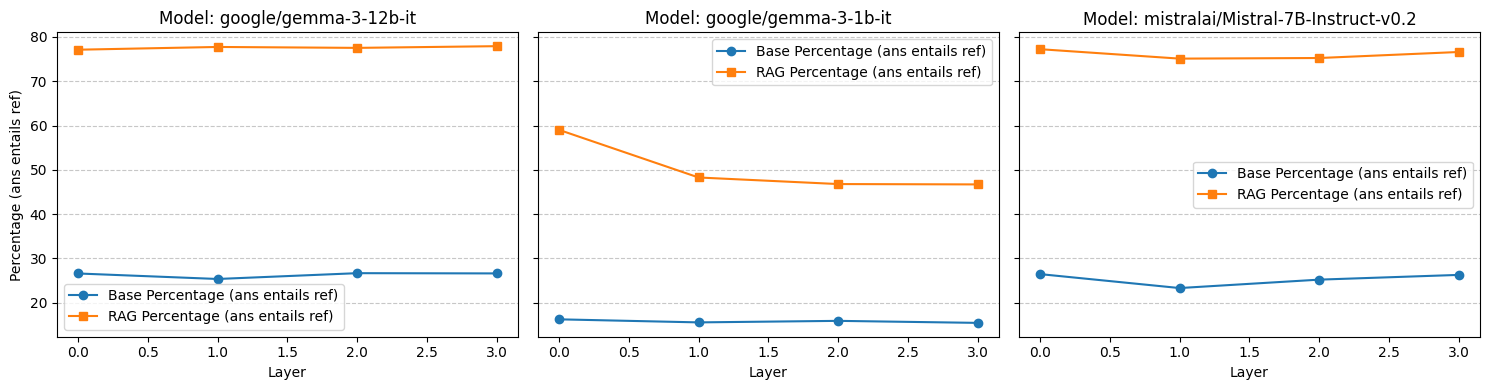

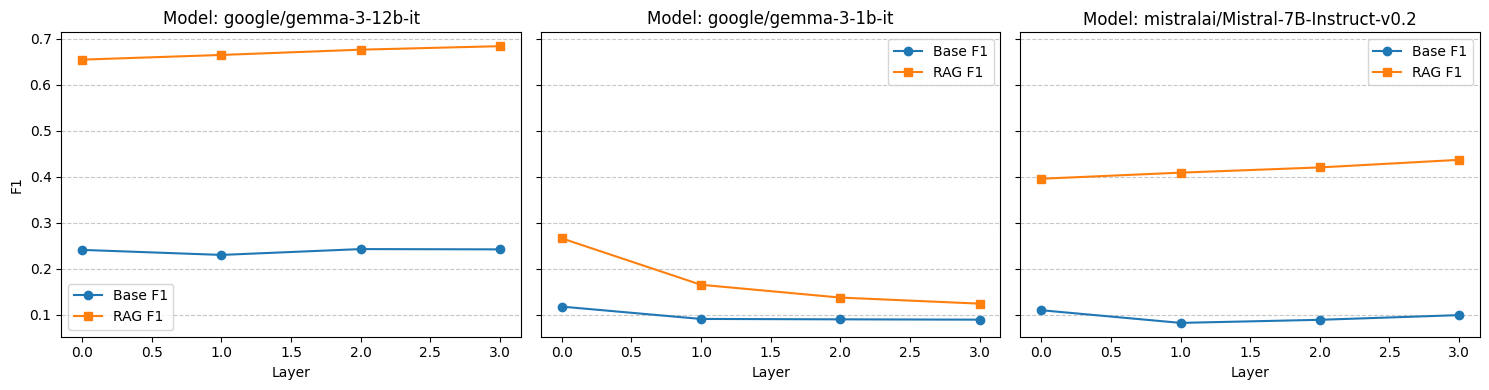

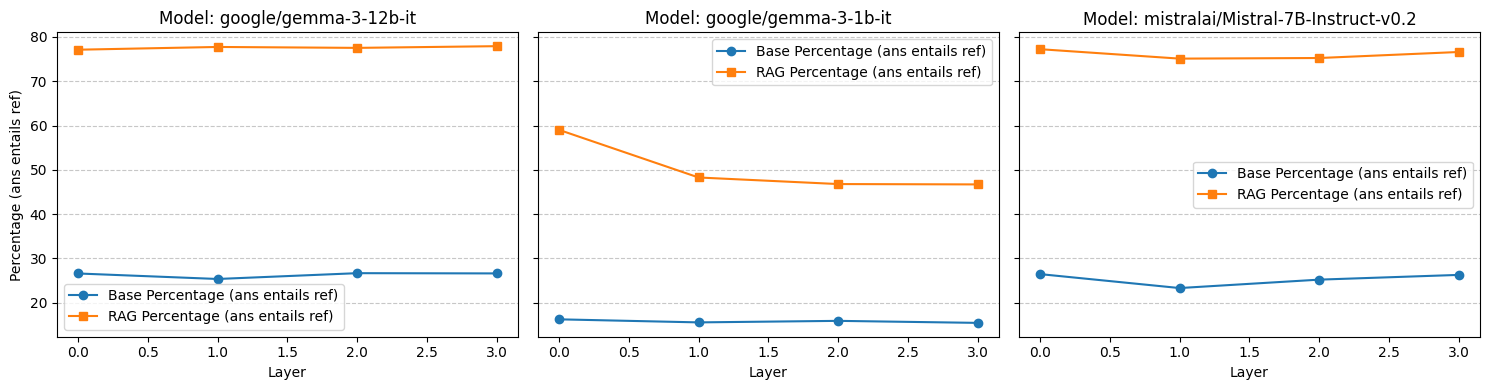

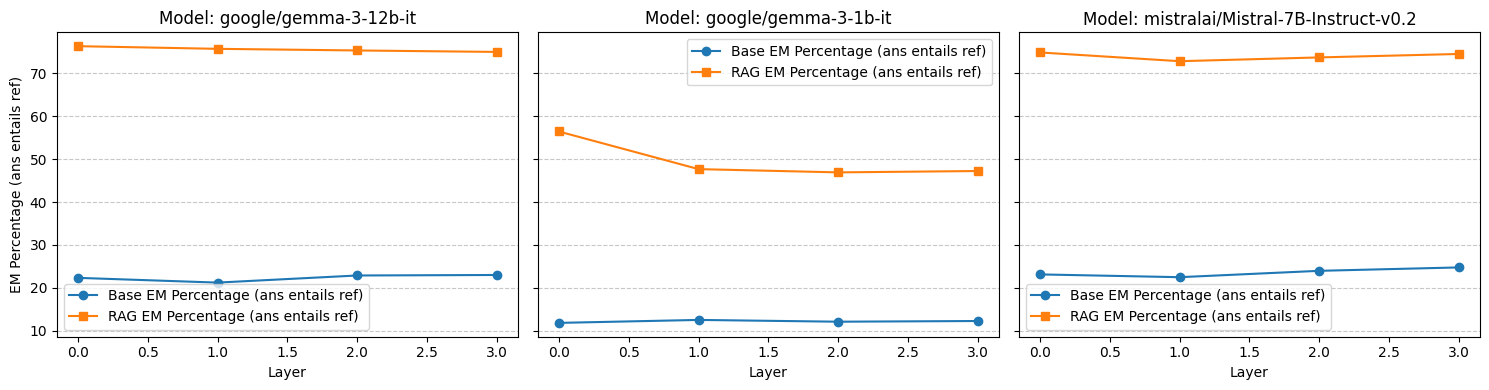

In [307]:
# summary = agg_df(df)
summary_list = summarise(summary, para_type='semantic')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'f1_1')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'em_pct')

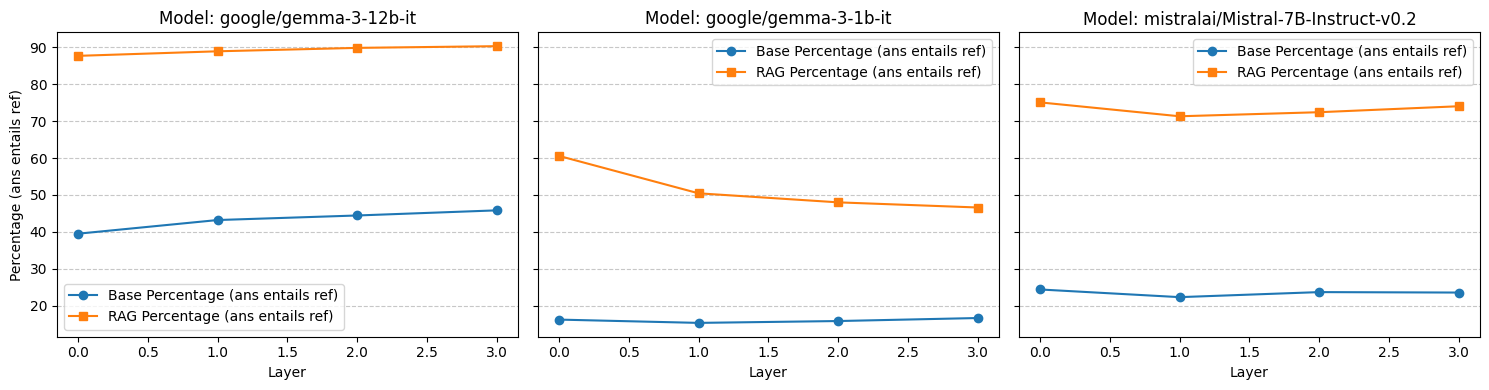

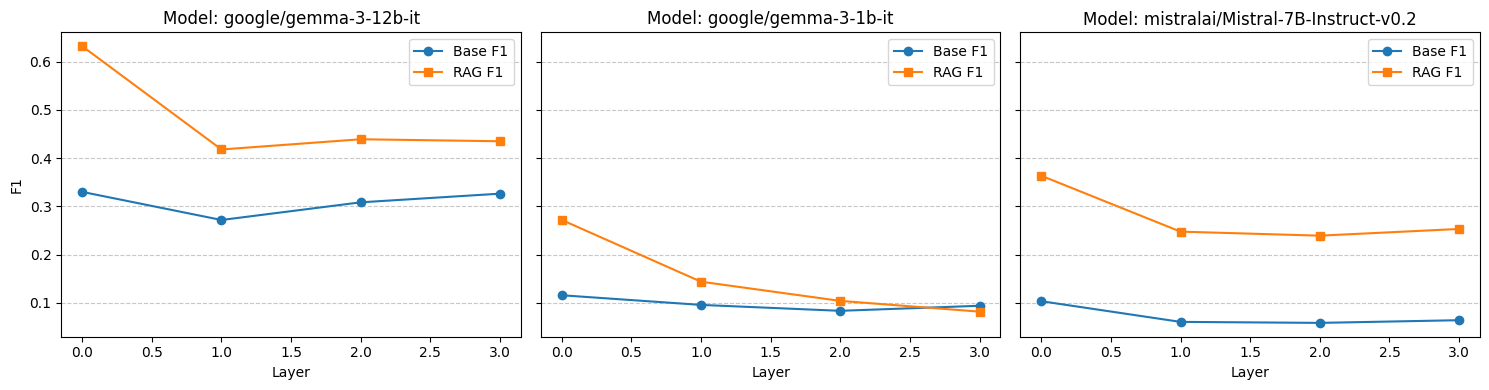

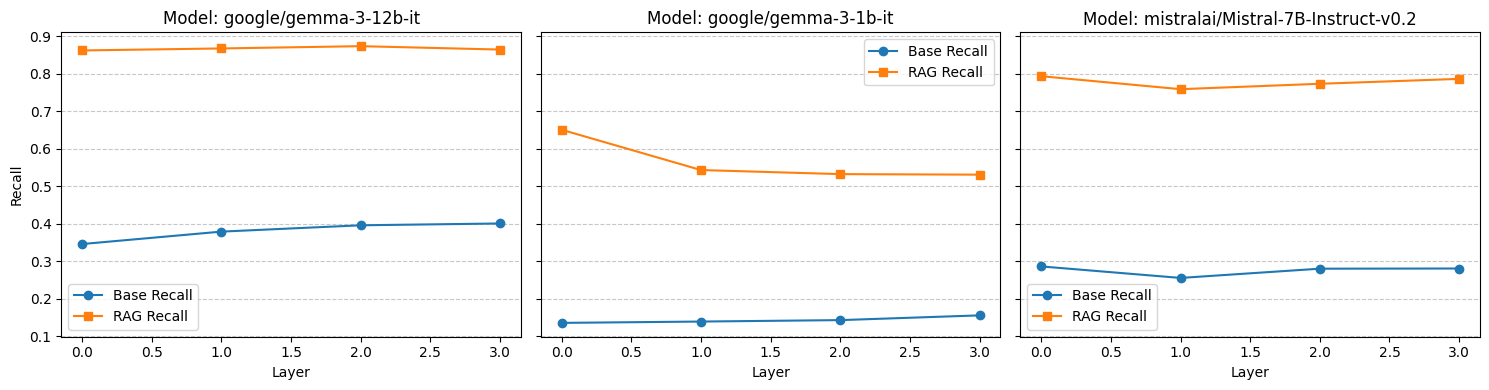

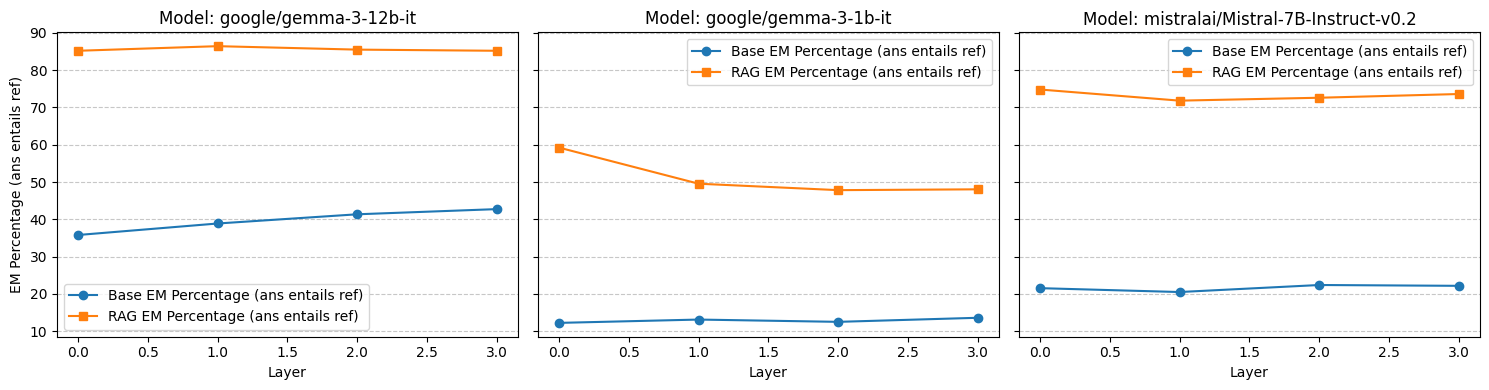

In [308]:
summary_list = summarise(summary, para_type='question_position_suffix')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'f1_1')
plot_from_summary(summary_list, 'rec_1')
plot_from_summary(summary_list, 'em_pct')

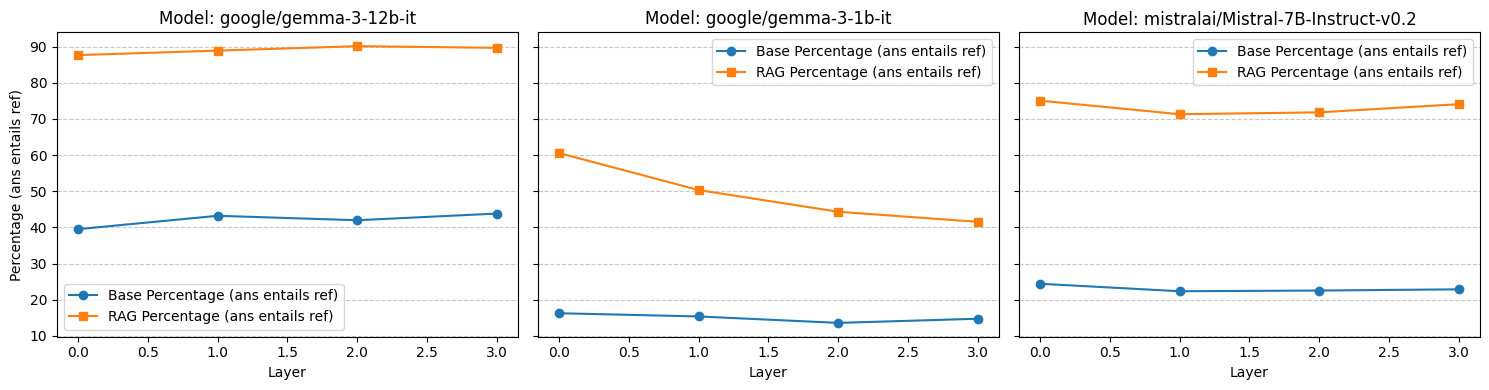

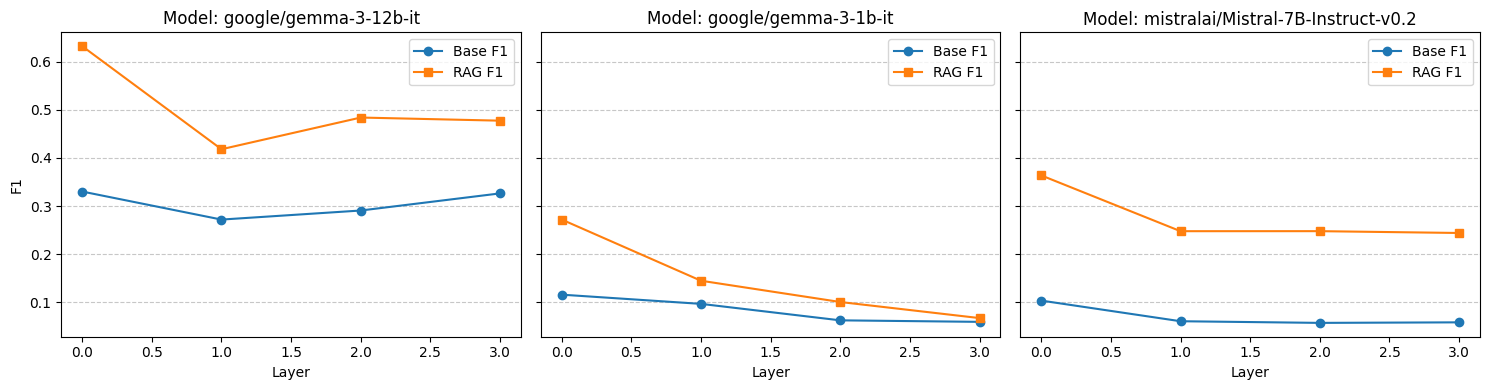

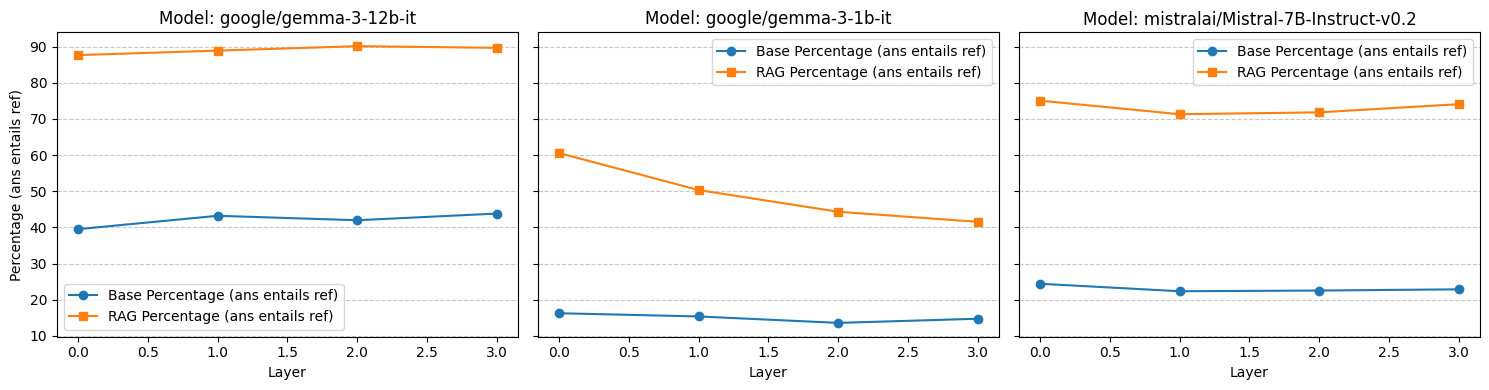

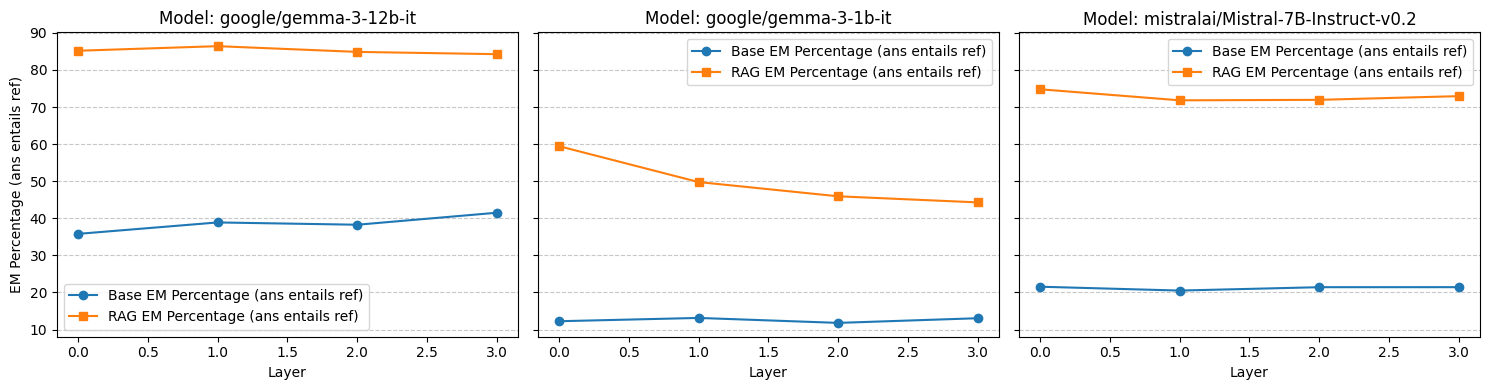

In [292]:
summary_list = summarise(summary, para_type='question_position_middle')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'f1_1')
plot_from_summary(summary_list, 'pct')
plot_from_summary(summary_list, 'em_pct')

# New section